# CO1.1 – Low-Light Pedestrian Detection
* Shafer Arjun Tagorda

## Dependencies
All the Python Libraries that is required is installed.
* PyTorch
* Torchvision
* Ultralytics
* Pillow
* OpenCV
* NumPy
* Pandas
* Matplotlib
* TensorBoard

In [1]:
%pip install -U ultralytics jupyter ipykernel pillow tqdm pandas matplotlib tensorboard


Note: you may need to restart the kernel to use updated packages.


## Environment and Path Configuration
This section defines the project directories and checks where the input files are available. In this case, the notebook is using the files on the local machine that is currently used.

In [2]:
from pathlib import Path
import sys
import random
import shutil
import subprocess
import zipfile
import xml.etree.ElementTree as ET
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from IPython.display import display, Markdown, Image as IPImage
from tqdm.auto import tqdm

import torch

PROJECT_ROOT = Path("/home/arjun/lli-pedestrian")

DATA_ROOT = PROJECT_ROOT / "data"

LLVIP_ROOT = DATA_ROOT / "llvip" / "LLVIP"
VISIBLE_ROOT = LLVIP_ROOT / "visible"
ANNOTATIONS_ROOT = LLVIP_ROOT / "Annotations"

PROCESSED_ROOT = DATA_ROOT / "processed"
PROCESSED_IMAGES_ROOT = PROCESSED_ROOT / "images"
PROCESSED_LABELS_ROOT = PROCESSED_ROOT / "labels"
PREVIEW_ROOT = PROCESSED_ROOT / "preview"

YOLO_ROOT = DATA_ROOT / "yolo"

ZERODCE_ROOT = PROJECT_ROOT / "Zero-DCE"
ZERODCE_CODE = ZERODCE_ROOT / "Zero-DCE_code"
ZERODCE_WEIGHTS = ZERODCE_CODE / "snapshots" / "Epoch99.pth"

RUNS_ROOT = PROJECT_ROOT / "runs"

for folder in [
    PROCESSED_IMAGES_ROOT,
    PROCESSED_LABELS_ROOT,
    PREVIEW_ROOT,
    YOLO_ROOT,
    RUNS_ROOT,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("\nProject root:", PROJECT_ROOT)
print("LLVIP root:", LLVIP_ROOT)
print("LLVIP exists:", LLVIP_ROOT.exists())
print("Zero-DCE weights:", ZERODCE_WEIGHTS)
print("Zero-DCE weights exist:", ZERODCE_WEIGHTS.exists())


Project root: /home/arjun/lli-pedestrian
LLVIP root: /home/arjun/lli-pedestrian/data/llvip/LLVIP
LLVIP exists: True
Zero-DCE weights: /home/arjun/lli-pedestrian/Zero-DCE/Zero-DCE_code/snapshots/Epoch99.pth
Zero-DCE weights exist: True


## LLVIP Download
This cells provides the option to download the required LLVIP dataset. If the dataset has not been installed, change "Download_LLVIP = False" to True. Otherwise, leave it as is.

In [3]:
DOWNLOAD_LLVIP = False

if DOWNLOAD_LLVIP:
    %pip install -U huggingface_hub

    from huggingface_hub import hf_hub_download

    raw_download_root = DATA_ROOT / "raw_download"
    raw_download_root.mkdir(parents=True, exist_ok=True)

    archive_path = hf_hub_download(
        repo_id="jsonhash/LLVIP",
        filename="LLVIP.zip",
        repo_type="dataset",
        local_dir=str(raw_download_root),
    )

    extraction_root = DATA_ROOT / "llvip"
    extraction_root.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(archive_path, "r") as archive:
        archive.extractall(extraction_root)

    print("LLVIP download and extraction complete.")

else:
    print("LLVIP download skipped.")
    print("The notebook is using the existing dataset at:")
    print(LLVIP_ROOT)

LLVIP download skipped.
The notebook is using the existing dataset at:
/home/arjun/lli-pedestrian/data/llvip/LLVIP


## Sample Original LLVIP Image
This cell provides a visual reference of what an original image within the dataset looks like before any alteration or enhancements takes place.

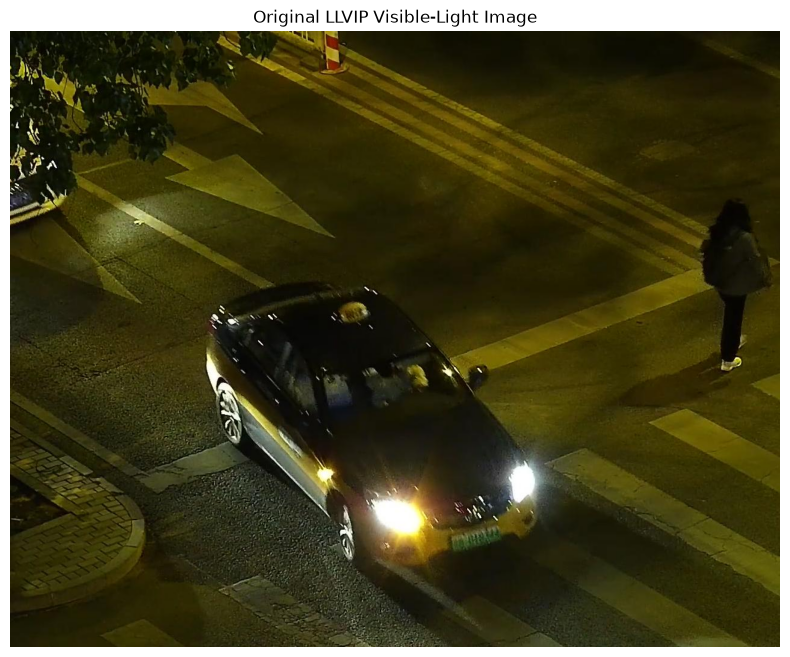

In [4]:
sample_image_path = VISIBLE_ROOT / "test" / "220185.jpg"

sample_image = Image.open(sample_image_path).convert("RGB")

plt.figure(figsize=(12, 8))
plt.imshow(sample_image)
plt.title("Original LLVIP Visible-Light Image")
plt.axis("off")
plt.show()

## Data Pre-Processing
* This section prepares the dataset for training by enhancing the low-light images with Zero-DCE. 

In [5]:
# Loading the Zero-DCE model

sys.path.insert(0, str(ZERODCE_CODE))

from model import enhance_net_nopool

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

zerodce_model = enhance_net_nopool().to(DEVICE)

checkpoint = torch.load(
    ZERODCE_WEIGHTS,
    map_location=DEVICE,
    weights_only=False,
)

zerodce_model.load_state_dict(checkpoint)
zerodce_model.eval()

print("Zero-DCE model loaded successfully.")
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Zero-DCE model loaded successfully.
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [6]:
# Defining the enhancement function

def enhance_with_zerodce(image_path, output_path):
    """
    Enhance one image with Zero-DCE and save it.
    """
    image = Image.open(image_path).convert("RGB")
    original_size = image.size

    image_array = (
        np.asarray(image).astype(np.float32) / 255.0
    )

    tensor = torch.from_numpy(image_array)
    tensor = tensor.permute(2, 0, 1)
    tensor = tensor.unsqueeze(0)
    tensor = tensor.to(DEVICE)

    with torch.no_grad():
        _, enhanced, _ = zerodce_model(tensor)

    enhanced = enhanced.squeeze(0).detach().cpu()
    enhanced = enhanced.permute(1, 2, 0).numpy()
    enhanced = np.clip(
        enhanced * 255.0,
        0,
        255,
    ).astype(np.uint8)

    output = Image.fromarray(enhanced)
    output = output.resize(original_size)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    output.save(output_path, quality=95)

    return output

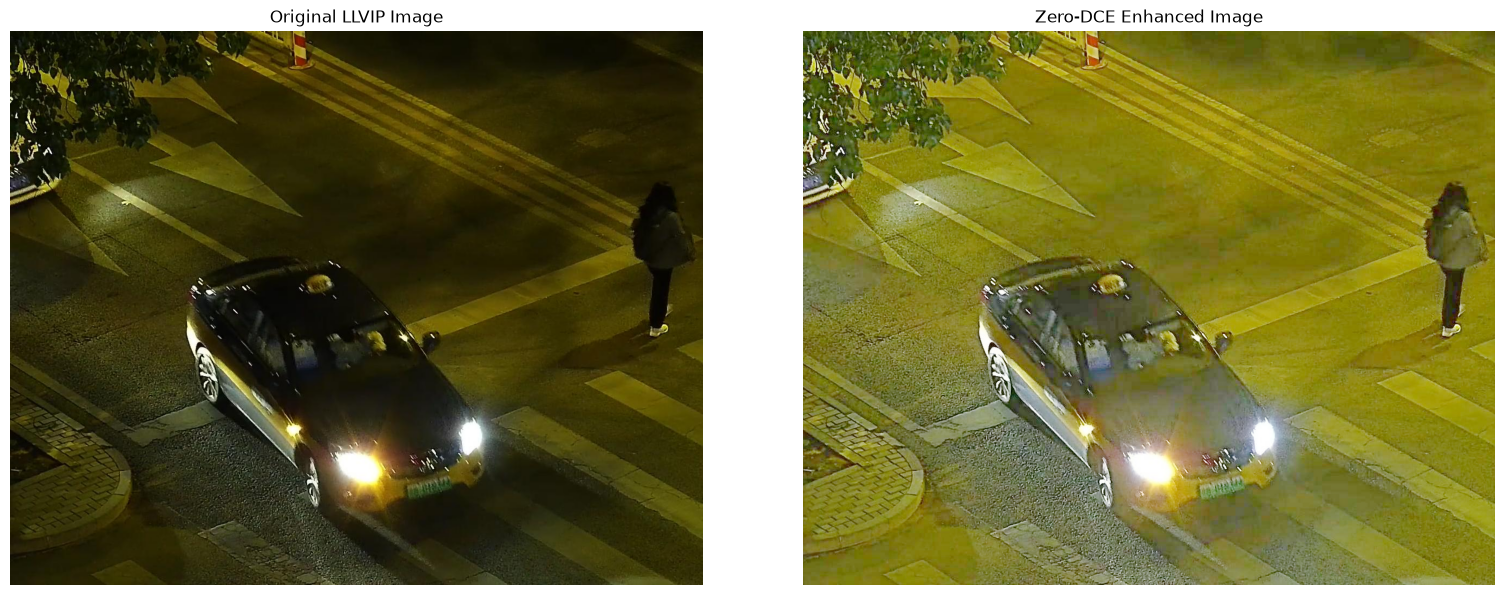

Preview saved to: /home/arjun/lli-pedestrian/data/processed/preview/220185_zerodce.jpg


In [7]:
# Testing the enhancement function on a sample image

preview_output = (
    PREVIEW_ROOT / "220185_zerodce.jpg"
)

enhanced_preview = enhance_with_zerodce(
    sample_image_path,
    preview_output,
)

original = Image.open(
    sample_image_path
).convert("RGB")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

axes[0].imshow(original)
axes[0].set_title("Original LLVIP Image")
axes[0].axis("off")

axes[1].imshow(enhanced_preview)
axes[1].set_title("Zero-DCE Enhanced Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Preview saved to:", preview_output)

In [8]:
# Enhancing all images in the LLVIP dataset with Zero-DCE

# Set to True to run the enhancement on the entire dataset.
RUN_ENHANCEMENT = False

if RUN_ENHANCEMENT:
    enhancement_start = time.time()

    total_processed = 0
    total_skipped = 0
    total_errors = 0

    for split in ["train", "test"]:
        input_dir = VISIBLE_ROOT / split
        output_dir = PROCESSED_IMAGES_ROOT / split

        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        image_paths = sorted(
            input_dir.glob("*.jpg")
        )

        split_processed = 0
        split_skipped = 0
        split_errors = 0

        print(
            f"\nStarting Zero-DCE enhancement for {split}: "
            f"{len(image_paths)} images"
        )

        for index, image_path in enumerate(
            image_paths,
            start=1,
        ):
            output_path = output_dir / image_path.name

            # Skip files already completed.
            if output_path.exists():
                split_skipped += 1
                total_skipped += 1
            else:
                try:
                    enhance_with_zerodce(
                        image_path,
                        output_path,
                    )

                    split_processed += 1
                    total_processed += 1

                except Exception as error:
                    split_errors += 1
                    total_errors += 1

                    print(
                        f"\nError processing "
                        f"{image_path.name}: {error}"
                    )

            # Plain text progress update.
            if index == 1 or index % 500 == 0 or index == len(image_paths):
                print(
                    f"{split}: {index}/{len(image_paths)} | "
                    f"new={split_processed}, "
                    f"skipped={split_skipped}, "
                    f"errors={split_errors}"
                )

        print(
            f"Finished {split}: "
            f"new={split_processed}, "
            f"skipped={split_skipped}, "
            f"errors={split_errors}"
        )

    elapsed_minutes = (
        time.time() - enhancement_start
    ) / 60

    print("\nEnhancement complete.")
    print(f"New images processed: {total_processed}")
    print(f"Existing images skipped: {total_skipped}")
    print(f"Errors: {total_errors}")
    print(f"Elapsed time: {elapsed_minutes:.2f} minutes")

else:
    print("Enhancement skipped.")

Enhancement skipped.


In [9]:
# Enhanced dataset verification

enhanced_train = sorted(
    (PROCESSED_IMAGES_ROOT / "train").glob("*.jpg")
)

enhanced_test = sorted(
    (PROCESSED_IMAGES_ROOT / "test").glob("*.jpg")
)

print("Enhanced training images:", len(enhanced_train))
print("Enhanced test images:", len(enhanced_test))
print("Total enhanced images:", len(enhanced_train) + len(enhanced_test))

assert len(enhanced_train) == 12025
assert len(enhanced_test) == 3463

print("Enhanced dataset verification passed.")

Enhanced training images: 12025
Enhanced test images: 3463
Total enhanced images: 15488
Enhanced dataset verification passed.


In [10]:
# Converting Pascal VOC XML annotations to YOLO format

def get_image_size(image_path):
    with Image.open(image_path) as image:
        return image.width, image.height


def convert_xml_to_yolo(
    xml_path,
    image_width,
    image_height,
):
    """
    Convert Pascal VOC XML boxes to YOLO format.

    YOLO format:
    class_id center_x center_y width height

    All coordinates are normalized from 0 to 1.
    """

    tree = ET.parse(xml_path)
    root = tree.getroot()

    yolo_lines = []

    for obj in root.findall("object"):
        class_name = obj.findtext(
            "name",
            "",
        ).strip().lower()

        if class_name != "person":
            continue

        box = obj.find("bndbox")

        if box is None:
            continue

        xmin = float(box.findtext("xmin"))
        ymin = float(box.findtext("ymin"))
        xmax = float(box.findtext("xmax"))
        ymax = float(box.findtext("ymax"))

        center_x = (
            (xmin + xmax) / 2
        ) / image_width

        center_y = (
            (ymin + ymax) / 2
        ) / image_height

        box_width = (
            xmax - xmin
        ) / image_width

        box_height = (
            ymax - ymin
        ) / image_height

        values = [
            0,
            max(0.0, min(1.0, center_x)),
            max(0.0, min(1.0, center_y)),
            max(0.0, min(1.0, box_width)),
            max(0.0, min(1.0, box_height)),
        ]

        yolo_lines.append(
            f"{int(values[0])} "
            f"{values[1]:.6f} "
            f"{values[2]:.6f} "
            f"{values[3]:.6f} "
            f"{values[4]:.6f}\n"
        )

    return yolo_lines

In [11]:
# Save the converted YOLO labels to the processed labels directory.

RUN_LABEL_CONVERSION = True

if RUN_LABEL_CONVERSION:
    conversion_start = time.time()

    for split in ["train", "test"]:
        image_dir = VISIBLE_ROOT / split
        output_dir = PROCESSED_LABELS_ROOT / split

        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        image_paths = sorted(
            image_dir.glob("*.jpg")
        )

        for image_path in tqdm(
            image_paths,
            desc=f"Converting {split} labels",
        ):
            xml_path = (
                ANNOTATIONS_ROOT
                / f"{image_path.stem}.xml"
            )

            output_path = (
                output_dir
                / f"{image_path.stem}.txt"
            )

            width, height = get_image_size(
                image_path
            )

            yolo_lines = convert_xml_to_yolo(
                xml_path,
                width,
                height,
            )

            output_path.write_text(
                "".join(yolo_lines)
            )

    elapsed_seconds = time.time() - conversion_start

    print(
        f"Annotation conversion complete in "
        f"{elapsed_seconds:.2f} seconds."
    )

else:
    print("Annotation conversion skipped.")

Converting train labels:   0%|          | 0/12025 [00:00<?, ?it/s]

Converting test labels:   0%|          | 0/3463 [00:00<?, ?it/s]

Annotation conversion complete in 24.65 seconds.


In [12]:
sample_label_path = (
    PROCESSED_LABELS_ROOT
    / "test"
    / "220185.txt"
)

print(sample_label_path.read_text())

0 0.939453 0.412109 0.094531 0.312500



In [13]:
# Organizing the dataset into YOLOv11 folder structure

RUN_DATASET_SPLIT = True
VALIDATION_RATIO = 0.20
RANDOM_SEED = 42

if RUN_DATASET_SPLIT:
    for split in ["train", "val", "test"]:
        (
            YOLO_ROOT
            / "images"
            / split
        ).mkdir(
            parents=True,
            exist_ok=True,
        )

        (
            YOLO_ROOT
            / "labels"
            / split
        ).mkdir(
            parents=True,
            exist_ok=True,
        )

    print("YOLO folders created.")
else:
    print("Dataset folder creation skipped.")

YOLO folders created.


In [14]:
# Copying images and labels to YOLO folders with train/val split

if RUN_DATASET_SPLIT:
    random.seed(RANDOM_SEED)

    source_train_images = sorted(
        (
            PROCESSED_IMAGES_ROOT
            / "train"
        ).glob("*.jpg")
    )

    random.shuffle(source_train_images)

    validation_count = int(
        len(source_train_images)
        * VALIDATION_RATIO
    )

    validation_images = (
        source_train_images[:validation_count]
    )

    training_images = (
        source_train_images[validation_count:]
    )

    def copy_image_label_pair(
        image_path,
        label_source_dir,
        output_split,
    ):
        label_path = (
            label_source_dir
            / f"{image_path.stem}.txt"
        )

        if not label_path.exists():
            raise FileNotFoundError(
                f"Missing label: {label_path}"
            )

        output_image = (
            YOLO_ROOT
            / "images"
            / output_split
            / image_path.name
        )

        output_label = (
            YOLO_ROOT
            / "labels"
            / output_split
            / label_path.name
        )

        shutil.copy2(
            image_path,
            output_image,
        )

        shutil.copy2(
            label_path,
            output_label,
        )

    for image_path in tqdm(
        training_images,
        desc="Copying training set",
    ):
        copy_image_label_pair(
            image_path,
            PROCESSED_LABELS_ROOT / "train",
            "train",
        )

    for image_path in tqdm(
        validation_images,
        desc="Copying validation set",
    ):
        copy_image_label_pair(
            image_path,
            PROCESSED_LABELS_ROOT / "train",
            "val",
        )

    source_test_images = sorted(
        (
            PROCESSED_IMAGES_ROOT
            / "test"
        ).glob("*.jpg")
    )

    for image_path in tqdm(
        source_test_images,
        desc="Copying test set",
    ):
        copy_image_label_pair(
            image_path,
            PROCESSED_LABELS_ROOT / "test",
            "test",
        )

    print("Dataset split complete.")
    print("Training images:", len(training_images))
    print("Validation images:", len(validation_images))
    print("Test images:", len(source_test_images))

else:
    print("Dataset split skipped.")

Copying training set:   0%|          | 0/9620 [00:00<?, ?it/s]

Copying validation set:   0%|          | 0/2405 [00:00<?, ?it/s]

Copying test set:   0%|          | 0/3463 [00:00<?, ?it/s]

Dataset split complete.
Training images: 9620
Validation images: 2405
Test images: 3463


In [16]:
PROJECT_ROOT = Path("/home/arjun/lli-pedestrian")
DATA_YAML = PROJECT_ROOT / "low-light-pedestrian-detection" / "data.yaml"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_YAML:", DATA_YAML)
print("DATA_YAML exists:", DATA_YAML.exists())

if not DATA_YAML.exists():
    raise FileNotFoundError(
        f"Missing data.yaml at {DATA_YAML}"
    )

PROJECT_ROOT: /home/arjun/lli-pedestrian
DATA_YAML: /home/arjun/lli-pedestrian/low-light-pedestrian-detection/data.yaml
DATA_YAML exists: True


In [17]:
# Creating the data.yaml file for YOLOv11

data_yaml = f"""path: {YOLO_ROOT}

train: images/train
val: images/val
test: images/test

names:
  0: person
"""

data_yaml_path = YOLO_ROOT / "data.yaml"
data_yaml_path.write_text(data_yaml)

print(data_yaml_path.read_text())

path: /home/arjun/lli-pedestrian/data/yolo

train: images/train
val: images/val
test: images/test

names:
  0: person



In [18]:
from pathlib import Path

TEST_IMAGE_DIR = YOLO_ROOT / "images" / "test"
TEST_LABEL_DIR = YOLO_ROOT / "labels" / "test"

test_images = sorted(
    path for path in TEST_IMAGE_DIR.iterdir()
    if path.is_file()
    and path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

test_labels = sorted(TEST_LABEL_DIR.glob("*.txt"))

print("Test image directory:", TEST_IMAGE_DIR)
print("Test label directory:", TEST_LABEL_DIR)
print("Test images:", len(test_images))
print("Test labels:", len(test_labels))

if not test_images:
    raise FileNotFoundError(
        f"No test images were found in {TEST_IMAGE_DIR}"
    )

if not test_labels:
    raise FileNotFoundError(
        f"No test labels were found in {TEST_LABEL_DIR}"
    )

image_stems = {path.stem for path in test_images}
label_stems = {path.stem for path in test_labels}

print("Images without labels:", sorted(image_stems - label_stems)[:10])
print("Labels without images:", sorted(label_stems - image_stems)[:10])

Test image directory: /home/arjun/lli-pedestrian/data/yolo/images/test
Test label directory: /home/arjun/lli-pedestrian/data/yolo/labels/test
Test images: 3463
Test labels: 3463
Images without labels: []
Labels without images: []


In [19]:
# Verifying the YOLO dataset structure and counts

dataset_counts = {}

for split in ["train", "val", "test"]:
    image_count = len(
        list(
            (
                YOLO_ROOT
                / "images"
                / split
            ).glob("*.jpg")
        )
    )

    label_count = len(
        list(
            (
                YOLO_ROOT
                / "labels"
                / split
            ).glob("*.txt")
        )
    )

    dataset_counts[split] = {
        "images": image_count,
        "labels": label_count,
    }

    print(
        f"{split}: "
        f"images={image_count}, "
        f"labels={label_count}"
    )

assert dataset_counts["train"]["images"] == 9620
assert dataset_counts["train"]["labels"] == 9620

assert dataset_counts["val"]["images"] == 2405
assert dataset_counts["val"]["labels"] == 2405

assert dataset_counts["test"]["images"] == 3463
assert dataset_counts["test"]["labels"] == 3463

print("\nYOLO dataset verification passed.")

train: images=9620, labels=9620
val: images=2405, labels=2405
test: images=3463, labels=3463

YOLO dataset verification passed.


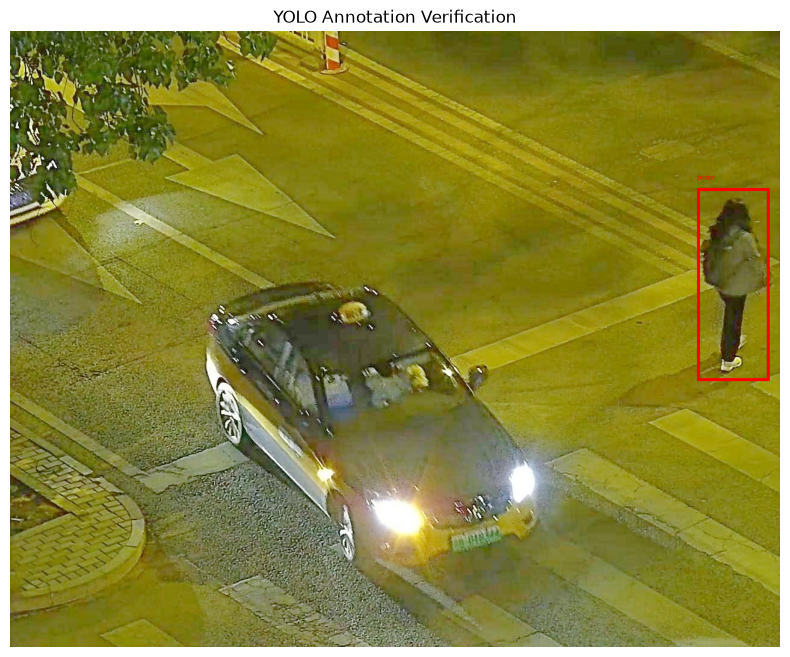

In [20]:
# Verifying YOLO annotations by drawing bounding boxes on a sample image

sample_yolo_image = (
    YOLO_ROOT
    / "images"
    / "test"
    / "220185.jpg"
)

sample_yolo_label = (
    YOLO_ROOT
    / "labels"
    / "test"
    / "220185.txt"
)

image = Image.open(
    sample_yolo_image
).convert("RGB")

draw = ImageDraw.Draw(image)

image_width, image_height = image.size

for line in sample_yolo_label.read_text().splitlines():
    values = line.split()

    if len(values) != 5:
        continue

    class_id, center_x, center_y, box_width, box_height = map(
        float,
        values,
    )

    center_x *= image_width
    center_y *= image_height
    box_width *= image_width
    box_height *= image_height

    xmin = center_x - box_width / 2
    ymin = center_y - box_height / 2
    xmax = center_x + box_width / 2
    ymax = center_y + box_height / 2

    draw.rectangle(
        [xmin, ymin, xmax, ymax],
        outline="red",
        width=5,
    )

    draw.text(
        [xmin, max(0, ymin - 25)],
        "person",
        fill="red",
    )

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.title("YOLO Annotation Verification")
plt.axis("off")
plt.show()

In [21]:
# Training YOLOv11 on the prepared dataset

from ultralytics import YOLO, settings

# Set to True to run training on the dataset.
RUN_TRAINING = True

TRAINING_NAME = "pedestrian_zerodce_yolo11n_notebook"
TRAINING_ROOT = RUNS_ROOT / TRAINING_NAME
BEST_MODEL_PATH = TRAINING_ROOT / "weights" / "best.pt"

# Enable TensorBoard logging for Ultralytics runs.
settings.update({"tensorboard": True})

model = YOLO("yolo11n.pt")

if RUN_TRAINING:
    training_results = model.train(
        data=str(data_yaml_path),
        epochs=50,
        imgsz=640,
        batch=4,
        device=0,
        workers=0,
        project=str(RUNS_ROOT),
        name=TRAINING_NAME,
        exist_ok=True,
        pretrained=True,
        patience=15,
        plots=True,
        save=True,
        seed=0,
        verbose=True,
        degrees=0.0,
        translate=0.1,
        scale=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.0,
    )

    print("Training complete.")

if BEST_MODEL_PATH.exists():
    model = YOLO(str(BEST_MODEL_PATH))
    print("Loaded trained model:", BEST_MODEL_PATH)
else:
    print("No trained YOLO11 checkpoint found yet:", BEST_MODEL_PATH)
    print("Set RUN_TRAINING = True to train yolo11n.pt on the prepared dataset.")

print("Training directory:", TRAINING_ROOT)
print("TensorBoard log directory:", TRAINING_ROOT)


Ultralytics 8.4.173 🚀 Python-3.14.4 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/arjun/lli-pedestrian/data/yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pedestrian_zerodce_y

/home/arjun/lli-pedestrian/env/lib/python3.14/site-packages/torch/jit/_trace.py:1000: FutureWarning: `torch.jit.trace` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/arjun/lli-pedestrian/env/lib/python3.14/site-packages/torch/jit/_trace.py:1139: FutureWarning: `torch.jit.trace_method` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


TensorBoard: model graph visualization added ✅
Using 9620 train, 2405 val images for fraction=1.0 at imgsz=640
Using 0 dataloader workers
Logging results to /home/arjun/lli-pedestrian/runs/pedestrian_zerodce_yolo11n_notebook
Starting training for 50 epochs...


/home/arjun/lli-pedestrian/env/lib/python3.14/site-packages/torch/jit/_trace.py:1022: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  traced_func = _trace_impl(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/50      1.56G      1.893      1.825      1.504         14        640: 100% ━━━━━━━━━━━━ 2405/2405 9.6it/s 4:120.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 301/301 8.3it/s 36.5s0.1ss
                   all       2405       6708      0.772      0.614      0.705      0.331

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      1.56G      1.852      1.512      1.487         10        640: 100% ━━━━━━━━━━━━ 2405/2405 8.7it/s 4:350.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 301/301 8.5it/s 35.3s0.1ss
                   all       2405       6708      0.857       0.68      0.787      0.376

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      1.56G      1.831      1.435      1.477         1

## Evaluation


In [22]:
# Enable TensorBoard logging for Ultralytics

import subprocess
import sys

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "tensorboard",
    ],
    check=True,
)

!yolo settings tensorboard=True

print("TensorBoard logging enabled.")
print("TensorBoard log root:", RUNS_ROOT)

✅ Updated 'tensorboard=True'
JSONDict("/home/arjun/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.8",
  "datasets_dir": "/home/arjun/lli-pedestrian/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "d4181f81c4eaa130e4e1dbcf1a56e8bafe186a606019a2884477fbdbbfdcf6ba",
  "sync": true,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "mlflow": true,
  "raytune": true,
  "tensorboard": true,
  "wandb": false,
  "vscode_msg": true,
  "openvino_msg": true
}
💡 Learn more about Ultralytics Settings at https://docs.ultralytics.com/usage/settings
TensorBoard logging enabled.
TensorBoard log root: /home/arjun/lli-pedestrian/runs


In [23]:
# Enable TensorBoard logging before YOLO training

from ultralytics import settings

settings.update({"tensorboard": True})

print("Ultralytics TensorBoard setting:",
      settings.get("tensorboard"))
print("Training log directory:", RUNS_ROOT)

Ultralytics TensorBoard setting: True
Training log directory: /home/arjun/lli-pedestrian/runs


In [24]:
from pathlib import Path

tensorboard_event_files = sorted(
    RUNS_ROOT.rglob("events.out.tfevents.*")
)

print("TensorBoard root:", RUNS_ROOT)
print("Event files found:", len(tensorboard_event_files))

for event_file in tensorboard_event_files:
    print(event_file)

if tensorboard_event_files:
    print("TensorBoard logs were generated successfully.")
else:
    print(
        "No TensorBoard event files found. "
        "Run the YOLO training cell again."
    )

TensorBoard root: /home/arjun/lli-pedestrian/runs
Event files found: 3
/home/arjun/lli-pedestrian/runs/pedestrian_zerodce_yolo11n_notebook/events.out.tfevents.1791221225.LAPTOP-09HKNB9N.1173961.0
/home/arjun/lli-pedestrian/runs/pedestrian_zerodce_yolo11n_notebook/events.out.tfevents.1791225223.LAPTOP-09HKNB9N.1173961.1
/home/arjun/lli-pedestrian/runs/pedestrian_zerodce_yolo11n_notebook/events.out.tfevents.1791249784.LAPTOP-09HKNB9N.1195733.0
TensorBoard logs were generated successfully.


In [28]:
# Evaluating the trained YOLO11 model on the validation set

VAL_EVALUATION_NAME = "pedestrian_zerodce_yolo11n_val"
RUN_VALIDATION = True

if RUN_VALIDATION:
    val_metrics = model.val(
        data=str(data_yaml_path),
        split="val",
        imgsz=640,
        batch=4,
        device=0,
        workers=0,
        plots=True,
        project=str(RUNS_ROOT),
        name=VAL_EVALUATION_NAME,
        exist_ok=True,
    )

    val_metrics_dict = {
        "precision": float(val_metrics.box.mp),
        "recall": float(val_metrics.box.mr),
        "mAP50": float(val_metrics.box.map50),
        "mAP50-95": float(val_metrics.box.map),
    }

    print(json.dumps(val_metrics_dict, indent=2))
else:
    print("Set RUN_VALIDATION = True to run YOLO11 validation.")


Ultralytics 8.4.173 🚀 Python-3.14.4 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 665.8±200.2 MB/s, size: 419.5 KB)
val: Scanning /home/arjun/lli-pedestrian/data/yolo/labels/val.cache... 2405 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2405/2405 127.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 602/602 16.6it/s 36.2s0.1ss
                   all       2405       6708      0.925      0.866      0.933      0.534
Speed: 0.5ms preprocess, 4.2ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /home/arjun/lli-pedestrian/runs/pedestrian_zerodce_yolo11n_val
{
  "precision": 0.9254361724870704,
  "recall": 0.8662790697674418,
  "mAP50": 0.9328034898603619,
  "mAP50-95": 0.533903376404625
}


confusion_matrix.png exists: True


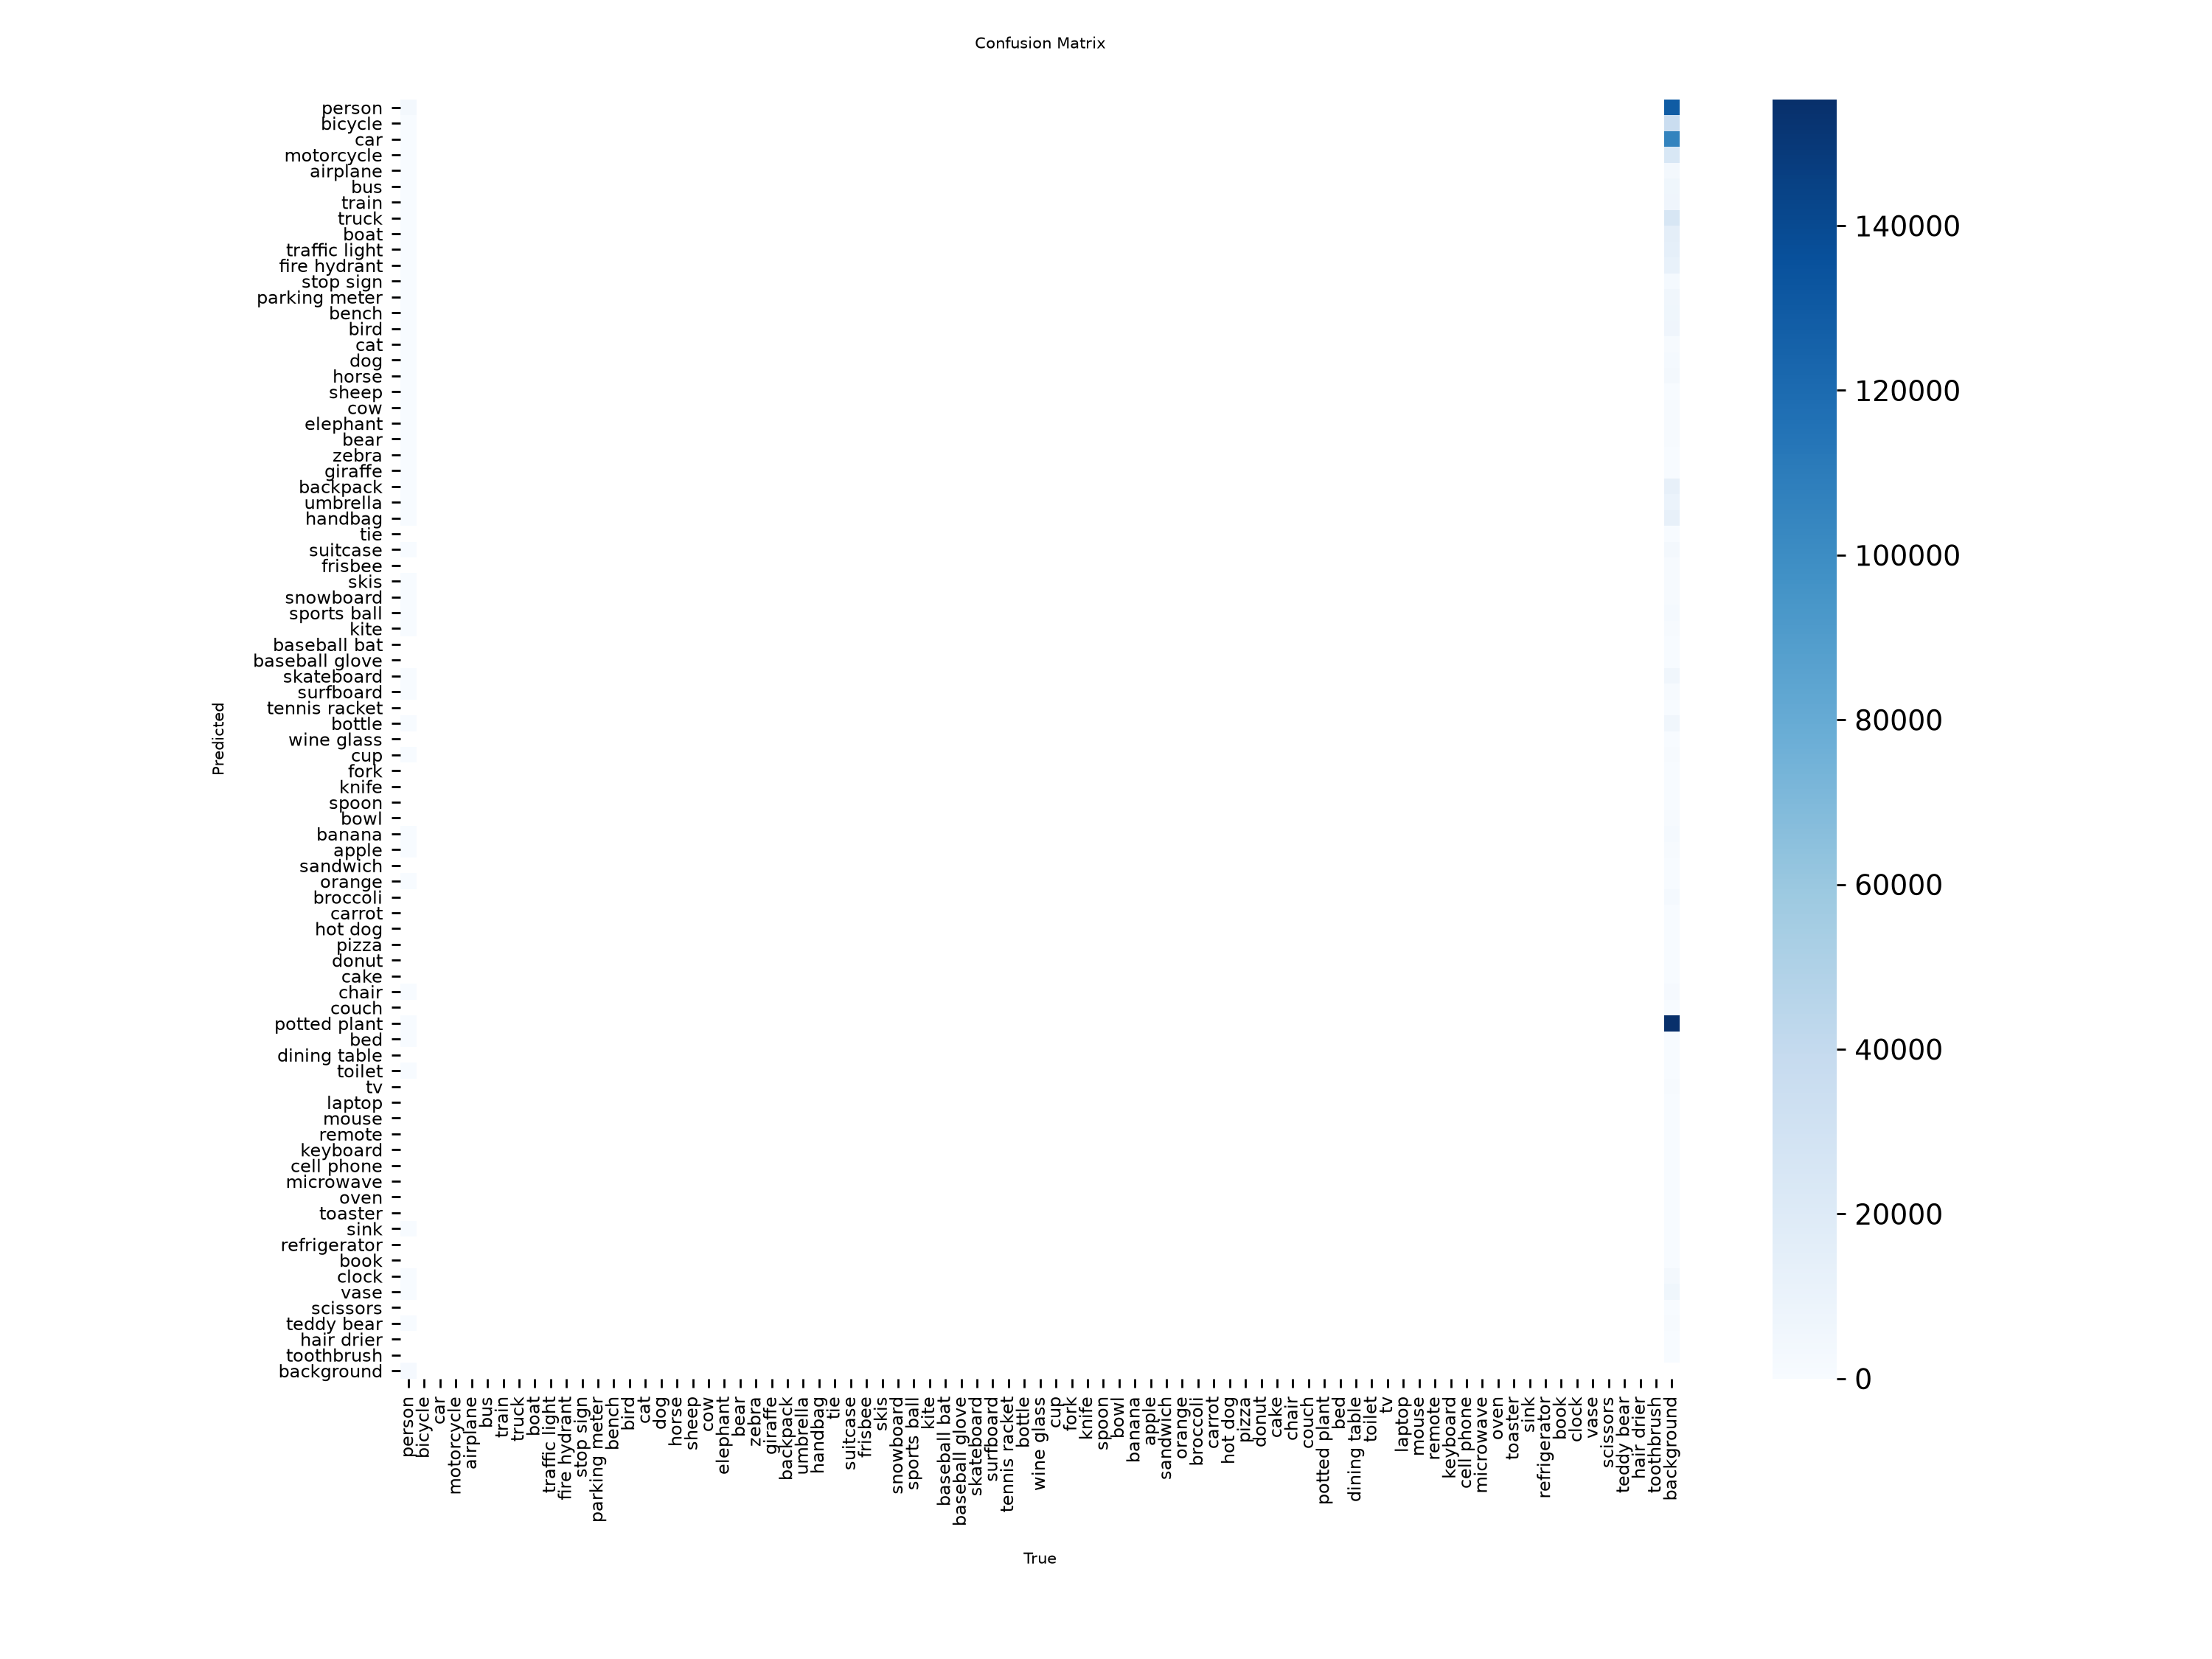

confusion_matrix_normalized.png exists: True


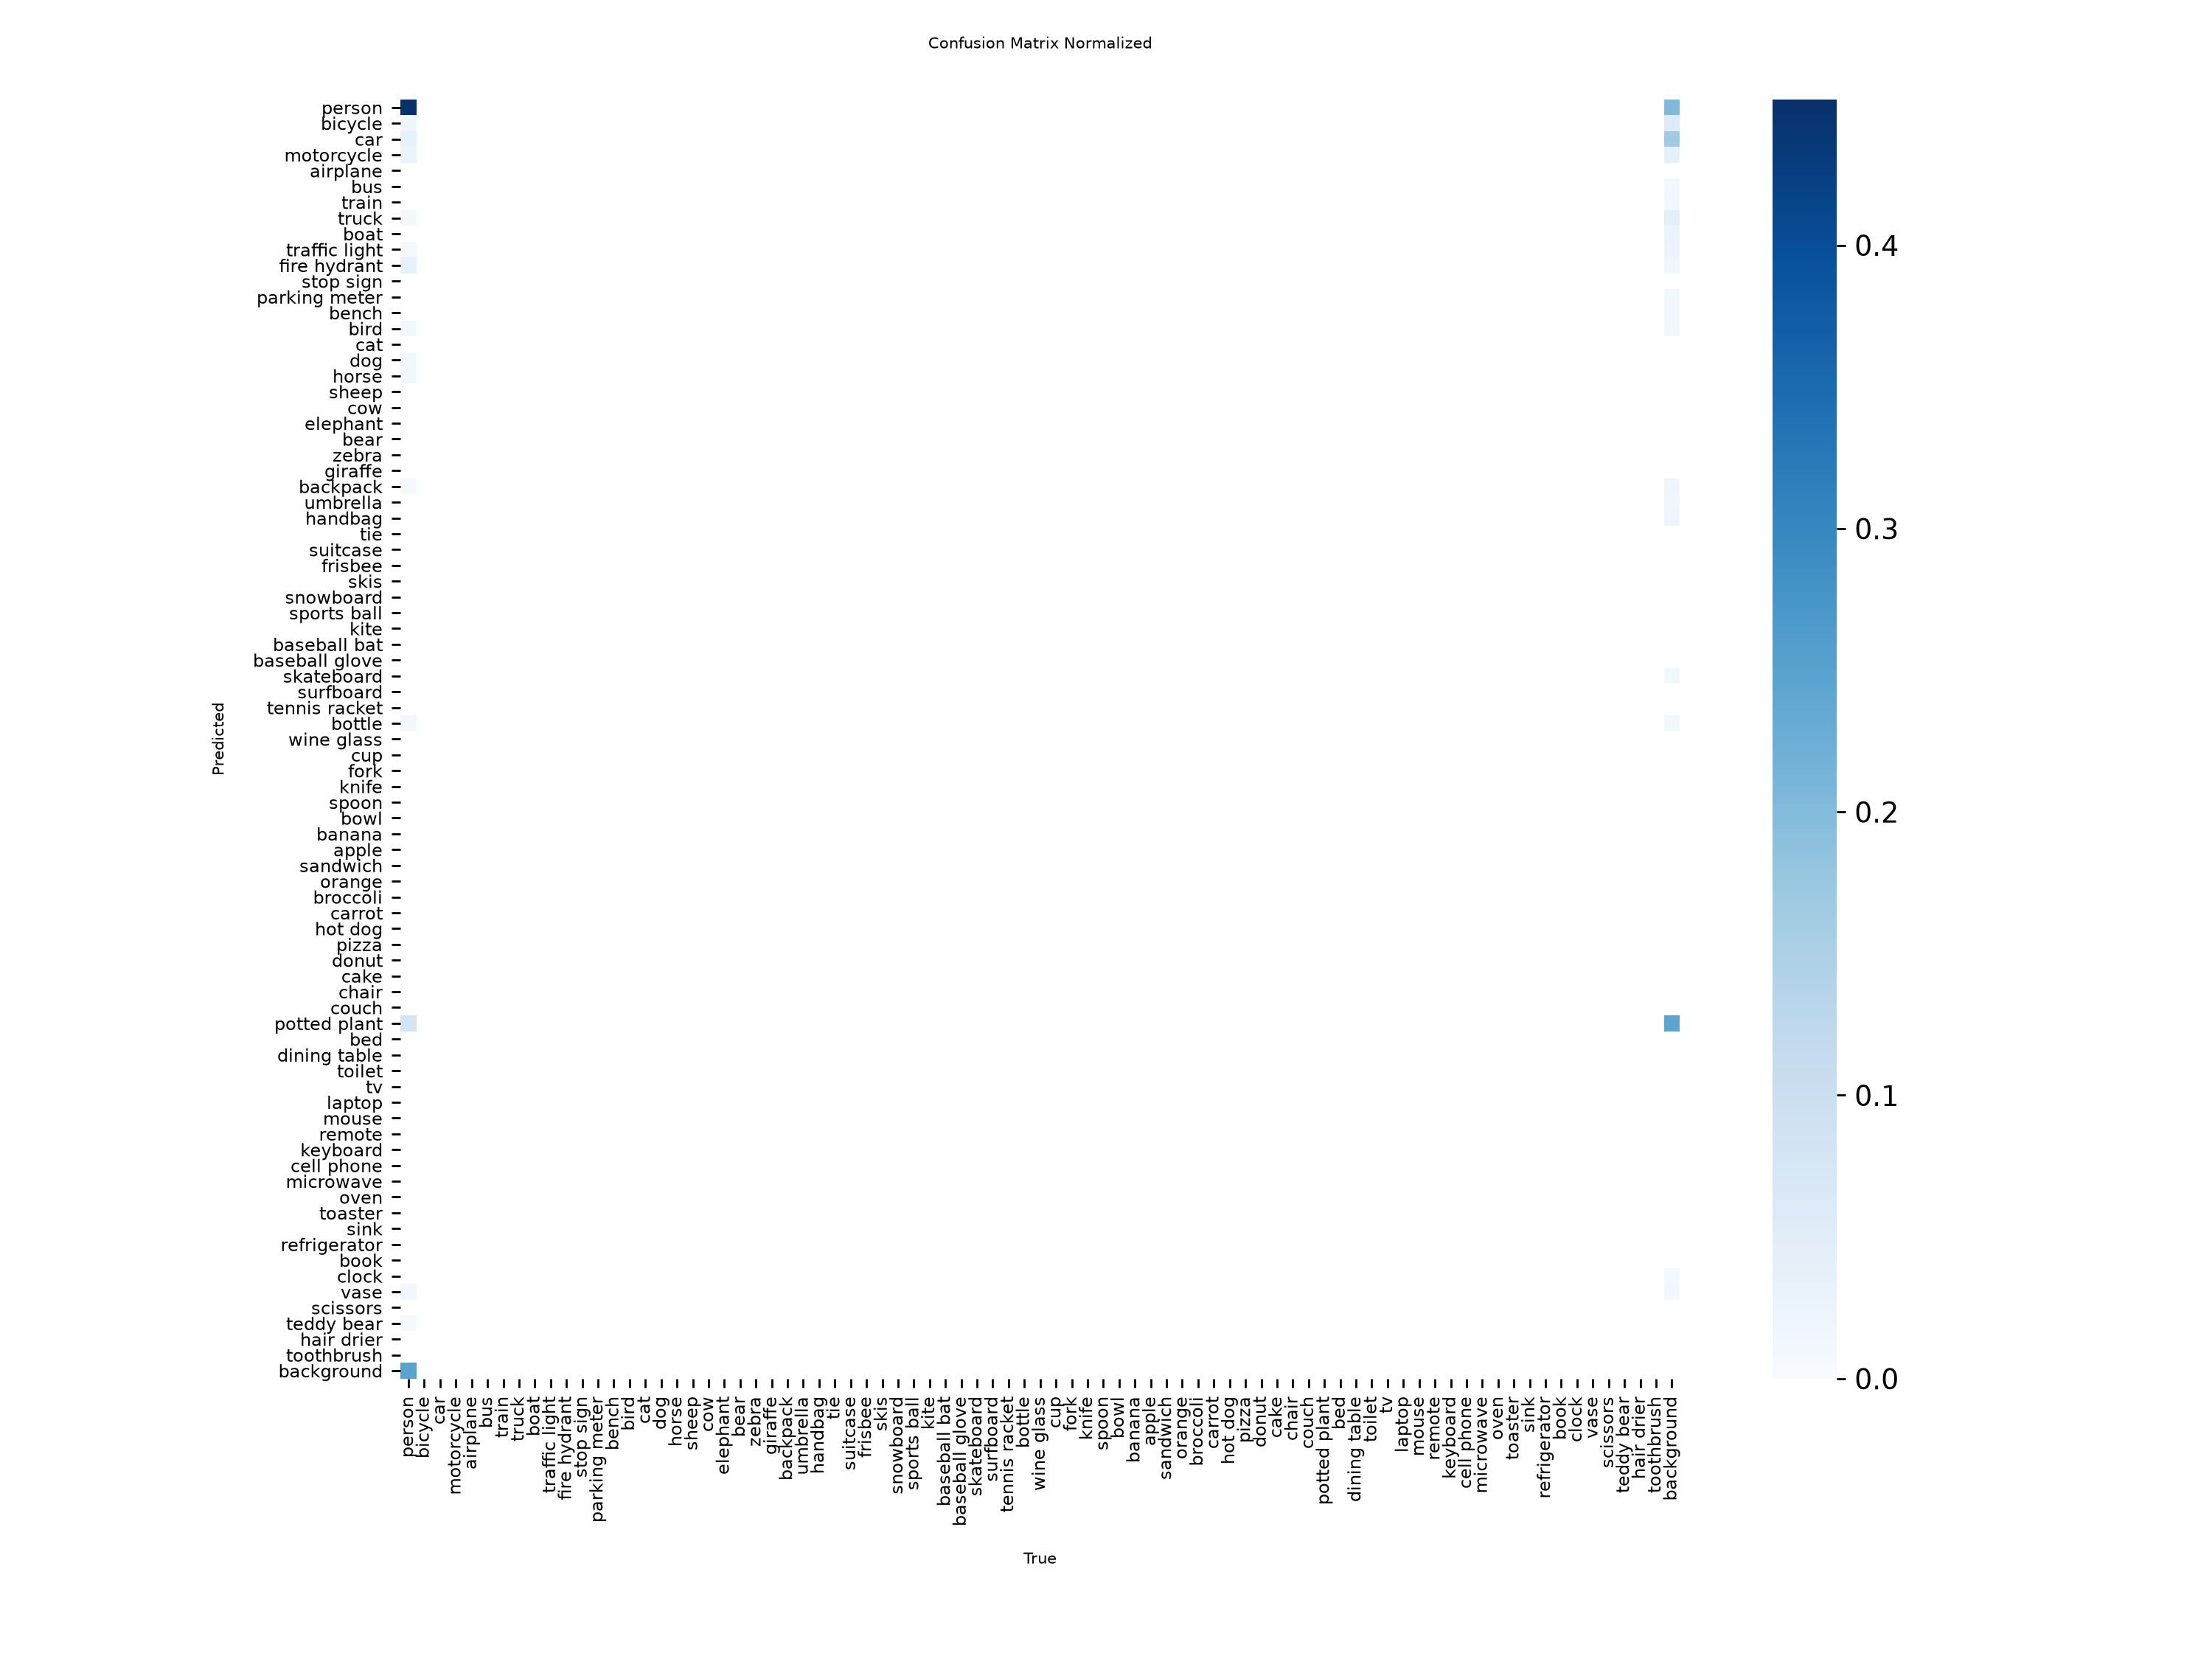

In [ ]:
# Evaluating the trained YOLO11 model on the validation set and displaying confusion matrices

VAL_RESULTS_ROOT = RUNS_ROOT / VAL_EVALUATION_NAME

for filename in [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
]:
    file_path = VAL_RESULTS_ROOT / filename
    print(filename, "exists:", file_path.exists())

    if file_path.exists():
        display(IPImage(filename=str(file_path)))


In [ ]:
# Displaying the confusion matrices for the validation set

TEST_EVALUATION_NAME = "pedestrian_zerodce_yolo11n_test"
RUN_TEST_EVALUATION = True

if RUN_TEST_EVALUATION:
    test_metrics = model.val(
        data=str(data_yaml_path),
        split="test",
        imgsz=640,
        batch=4,
        device=0,
        workers=0,
        plots=True,
        project=str(RUNS_ROOT),
        name=TEST_EVALUATION_NAME,
        exist_ok=True,
    )

    test_metrics_dict = {
        "precision": float(test_metrics.box.mp),
        "recall": float(test_metrics.box.mr),
        "mAP50": float(test_metrics.box.map50),
        "mAP50-95": float(test_metrics.box.map),
    }

    print(json.dumps(test_metrics_dict, indent=2))
else:
    print("Set RUN_TEST_EVALUATION = True to run held-out YOLO11 test evaluation.")


Ultralytics 8.4.173 🚀 Python-3.14.4 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 12,675 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 233.4±74.6 MB/s, size: 369.3 KB)
val: Scanning /home/arjun/lli-pedestrian/data/yolo/labels/test... 3463 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3463/3463 1.5Kit/s 2.2s0.0s
val: New cache created: /home/arjun/lli-pedestrian/data/yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 866/866 19.5it/s 44.3s0.1ss
                   all       3463       8302      0.782      0.726      0.785      0.386
Speed: 0.4ms preprocess, 3.4ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /home/arjun/lli-pedestrian/runs/pedestrian_zerodce_yolo11n_test
{
  "precision": 0.7816412385244076,
  "recall": 0.7264514574801253,
  "mAP50": 0.7850141184700705,
  "

confusion_matrix.png exists: True


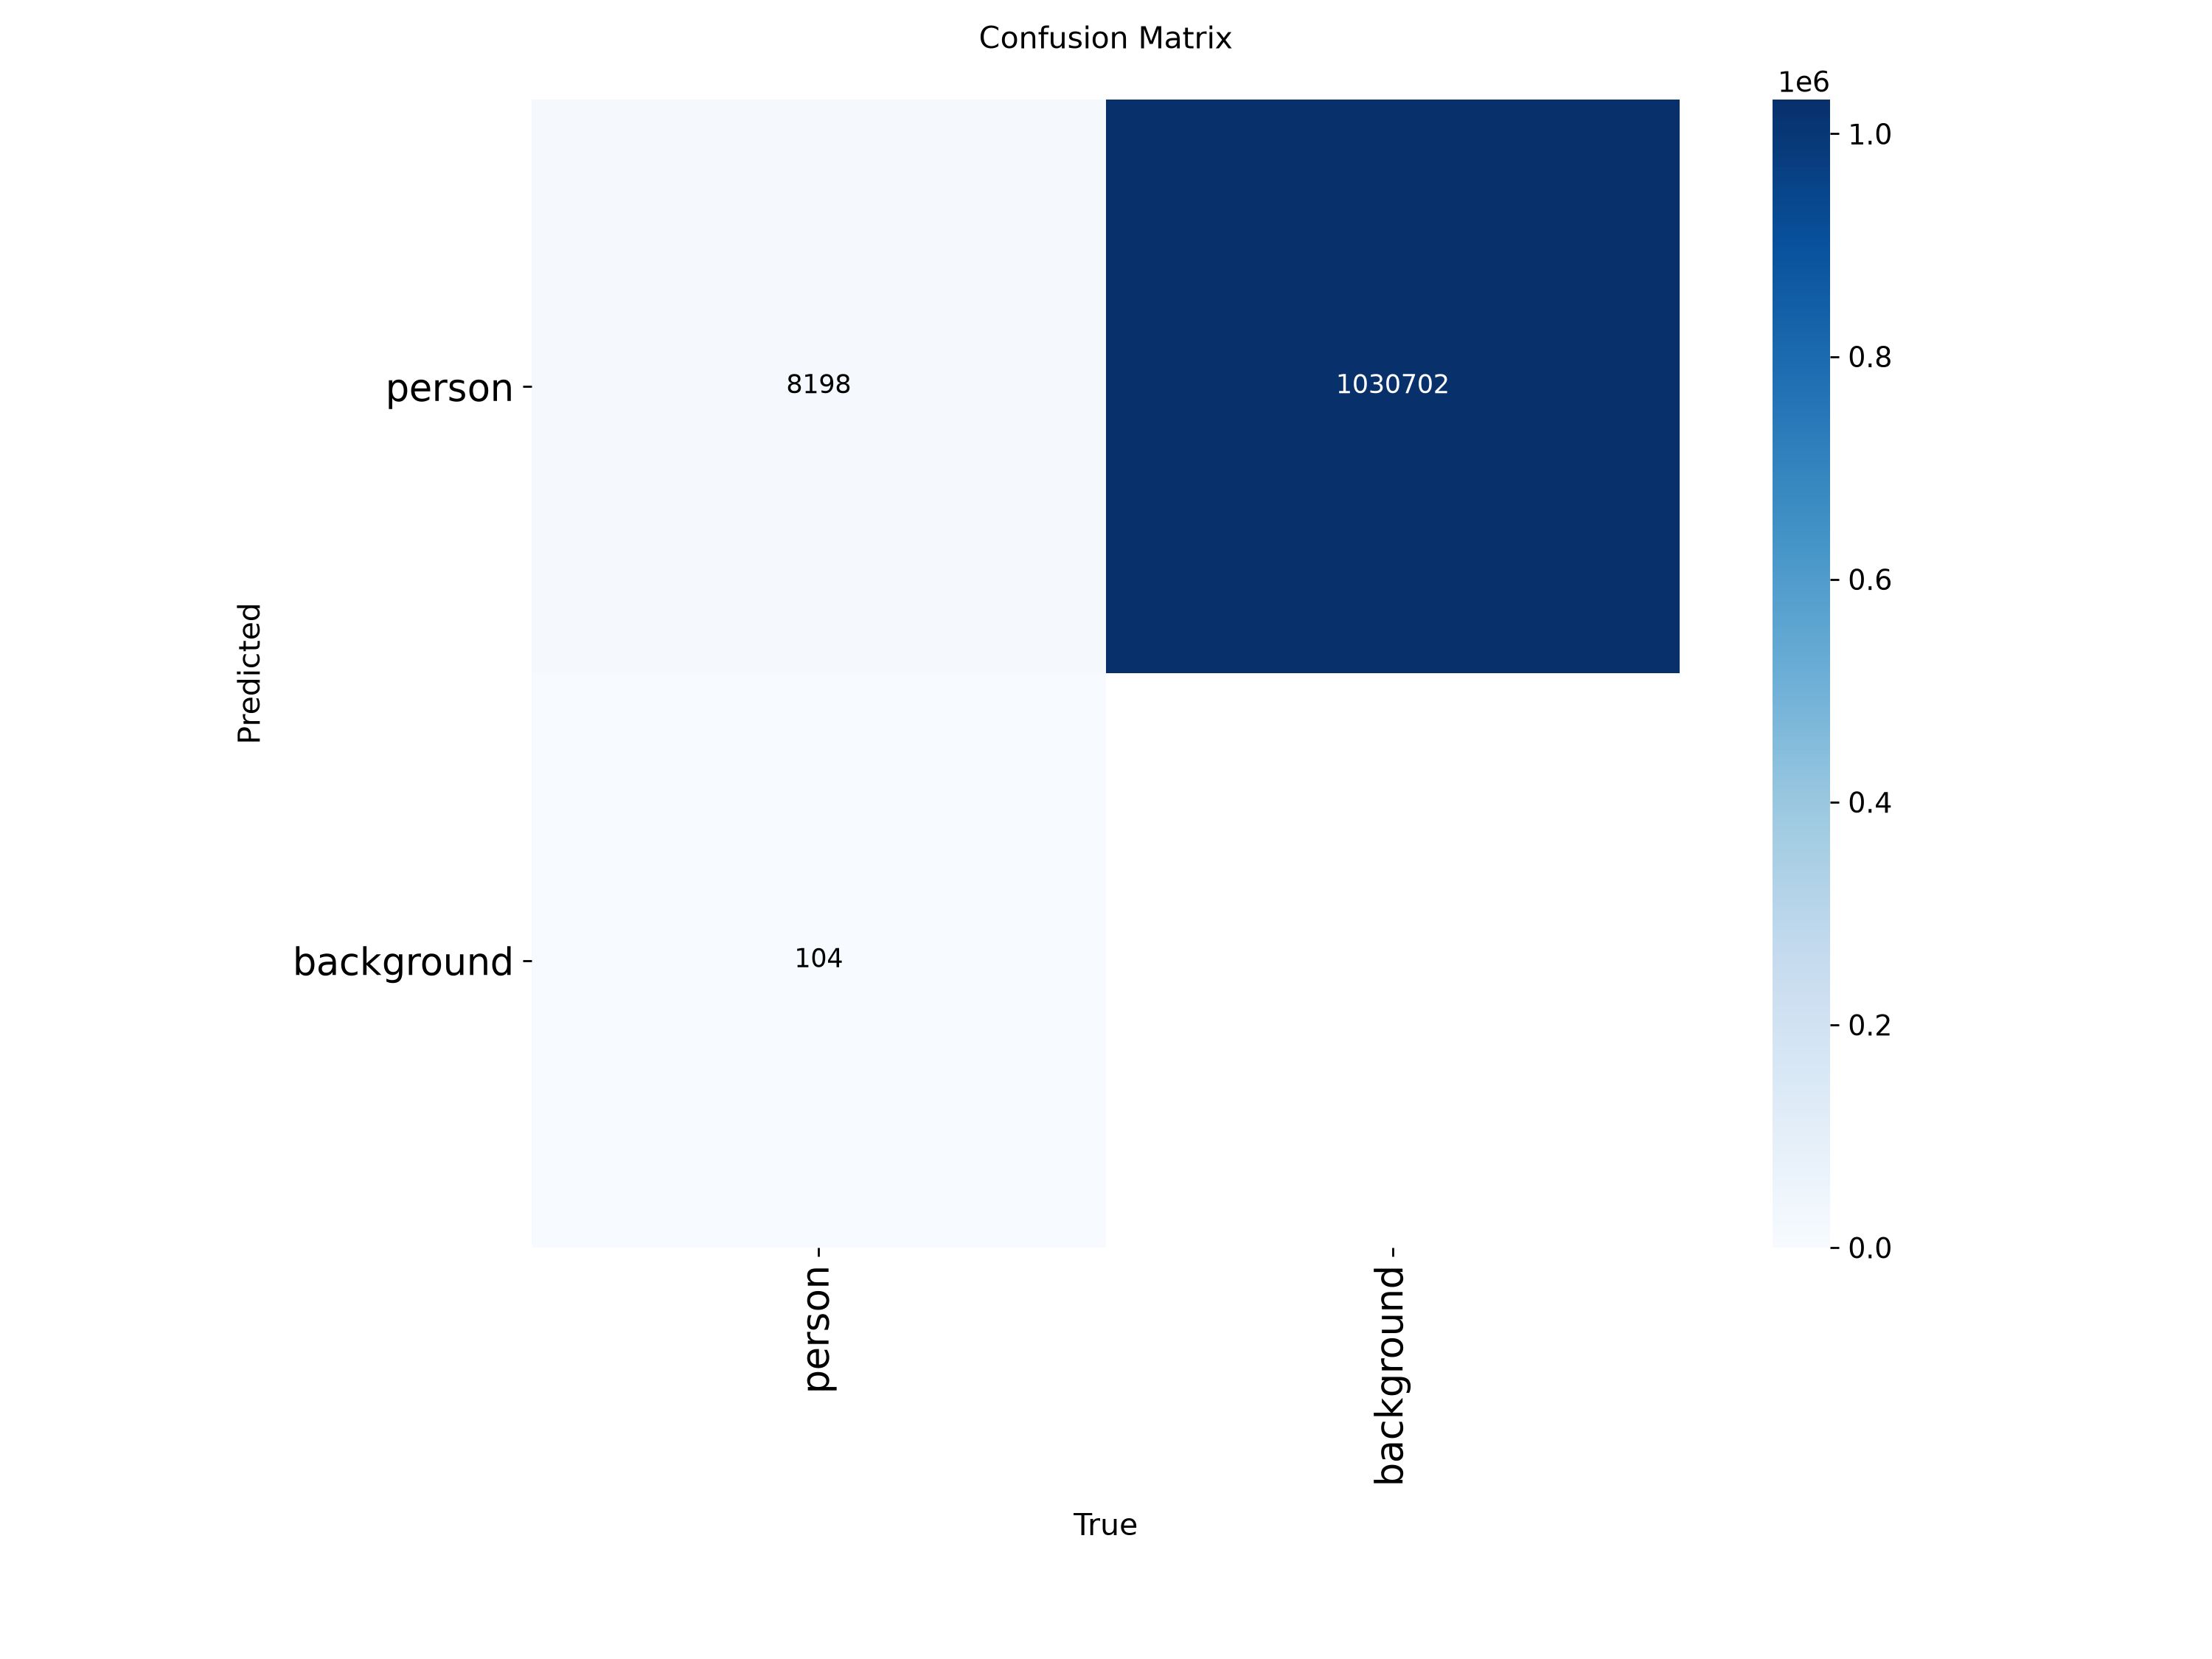

confusion_matrix_normalized.png exists: True


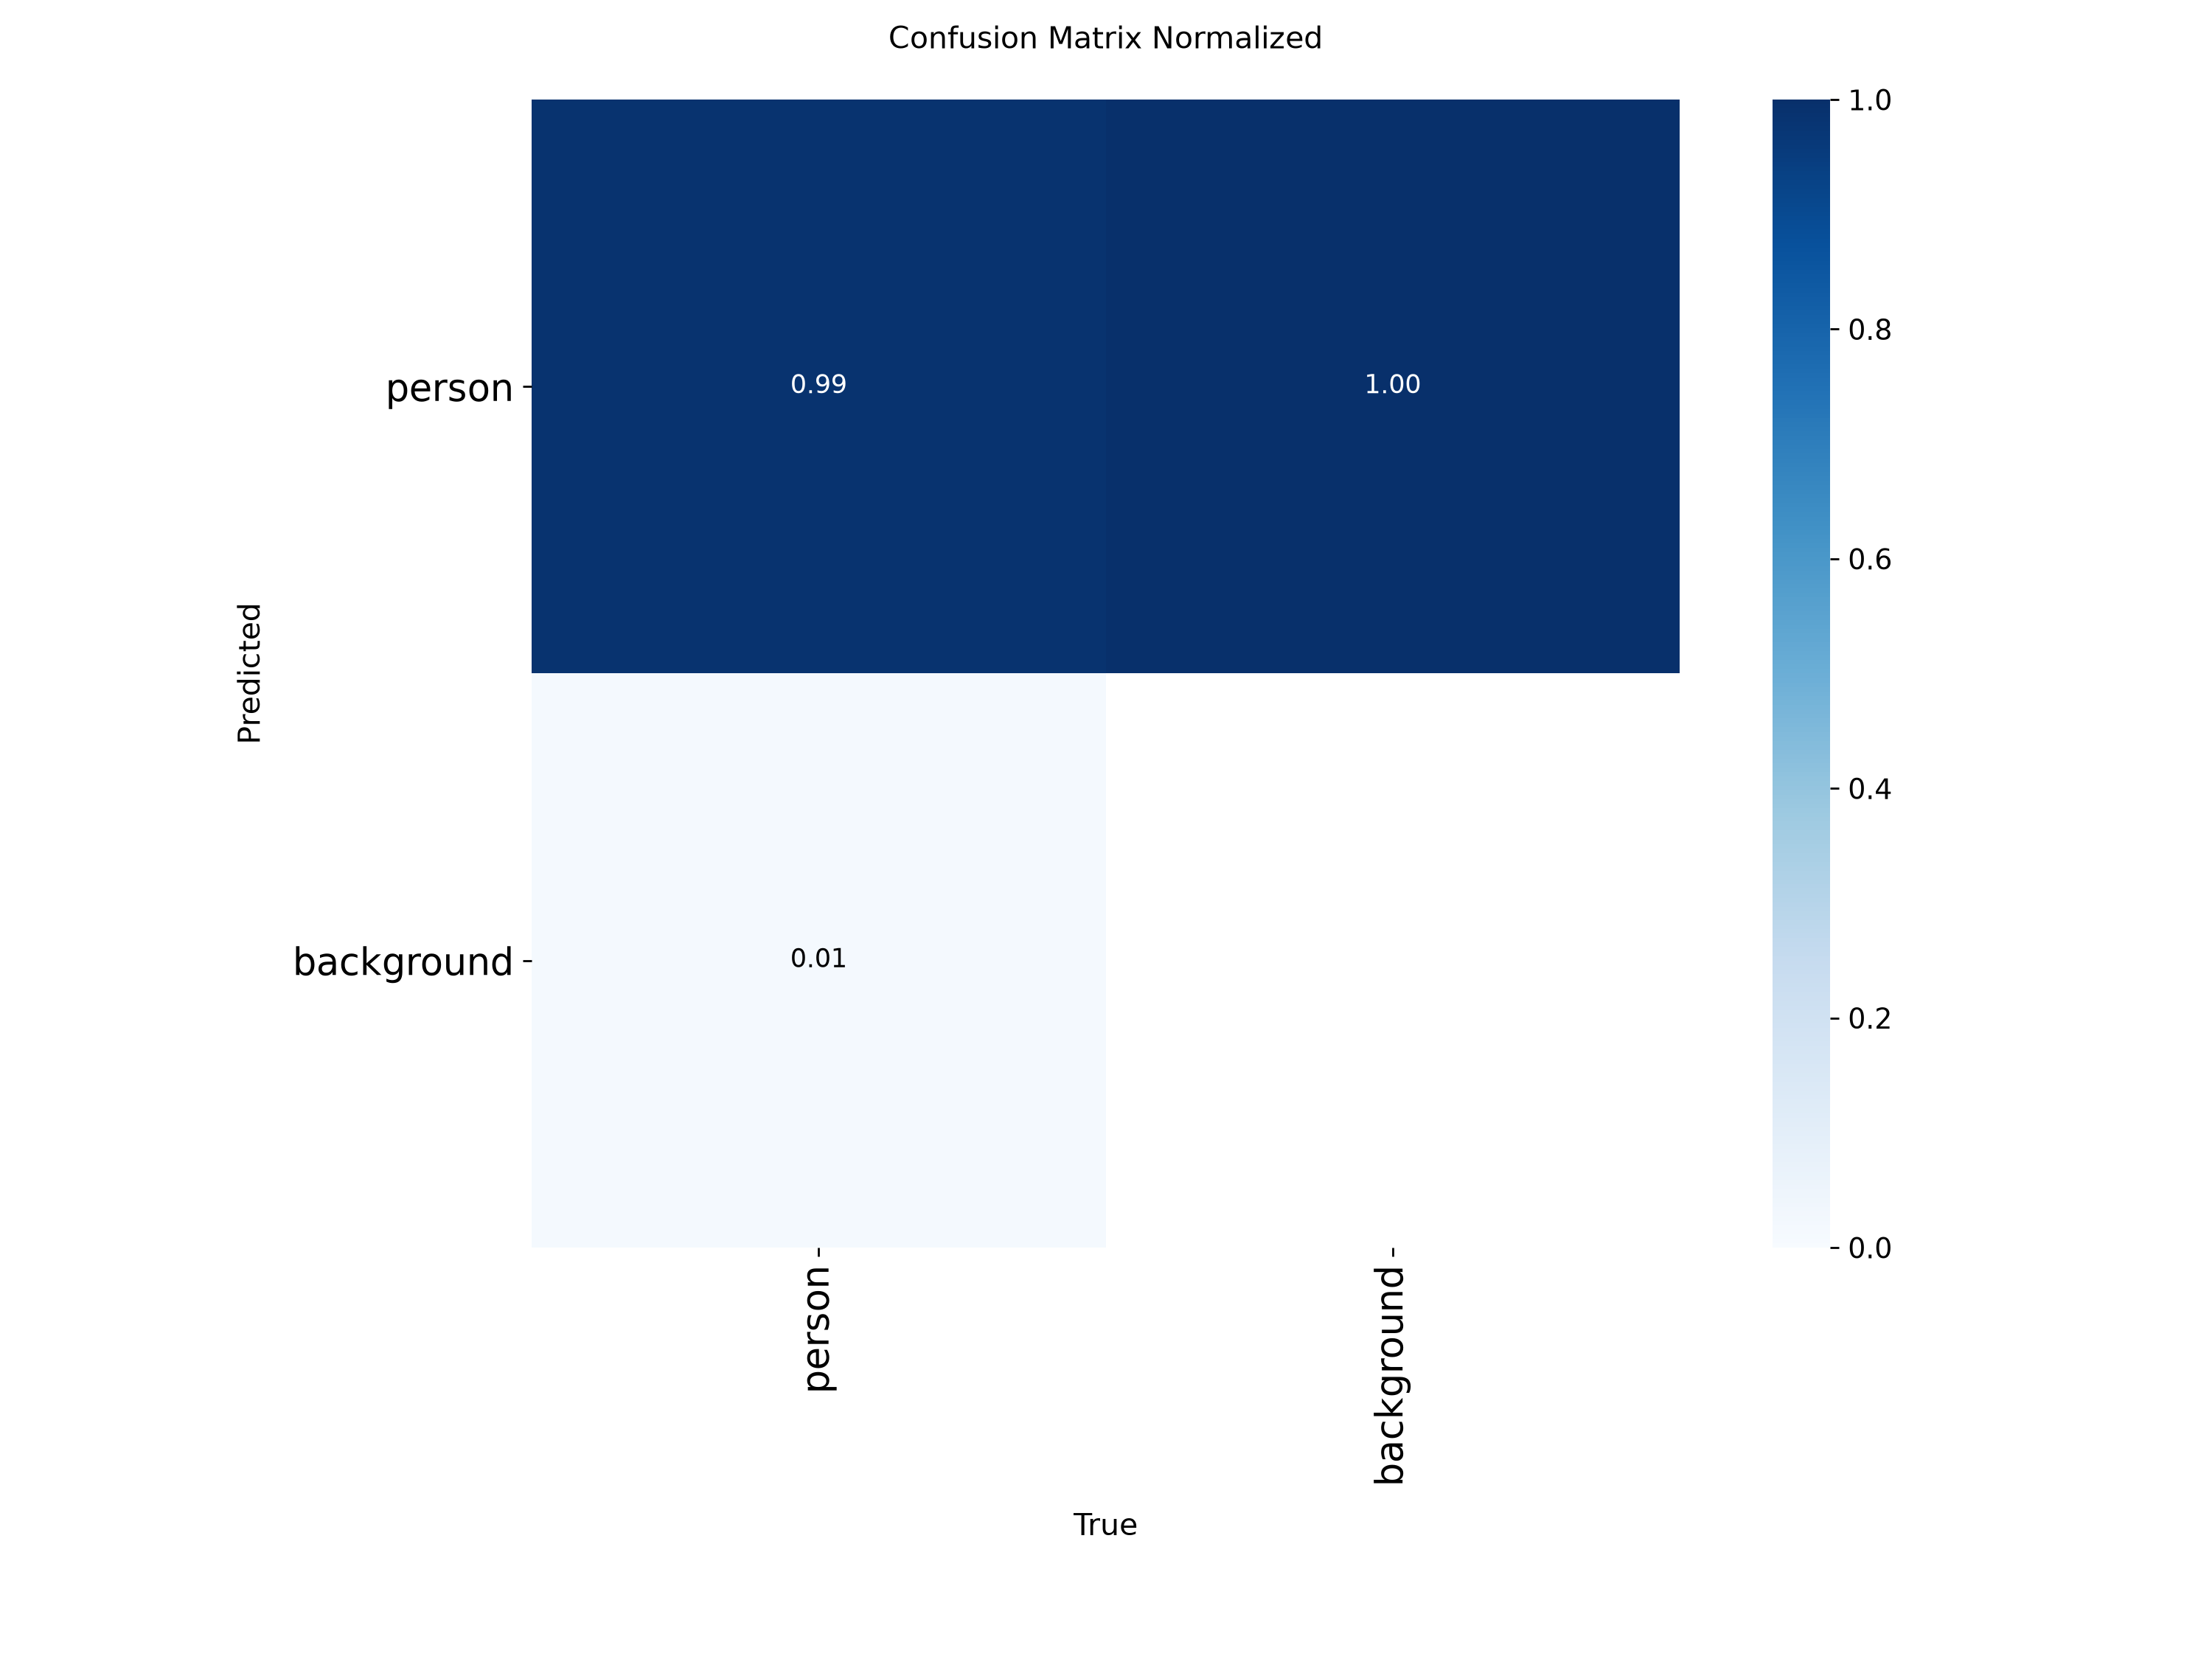

BoxPR_curve.png exists: True


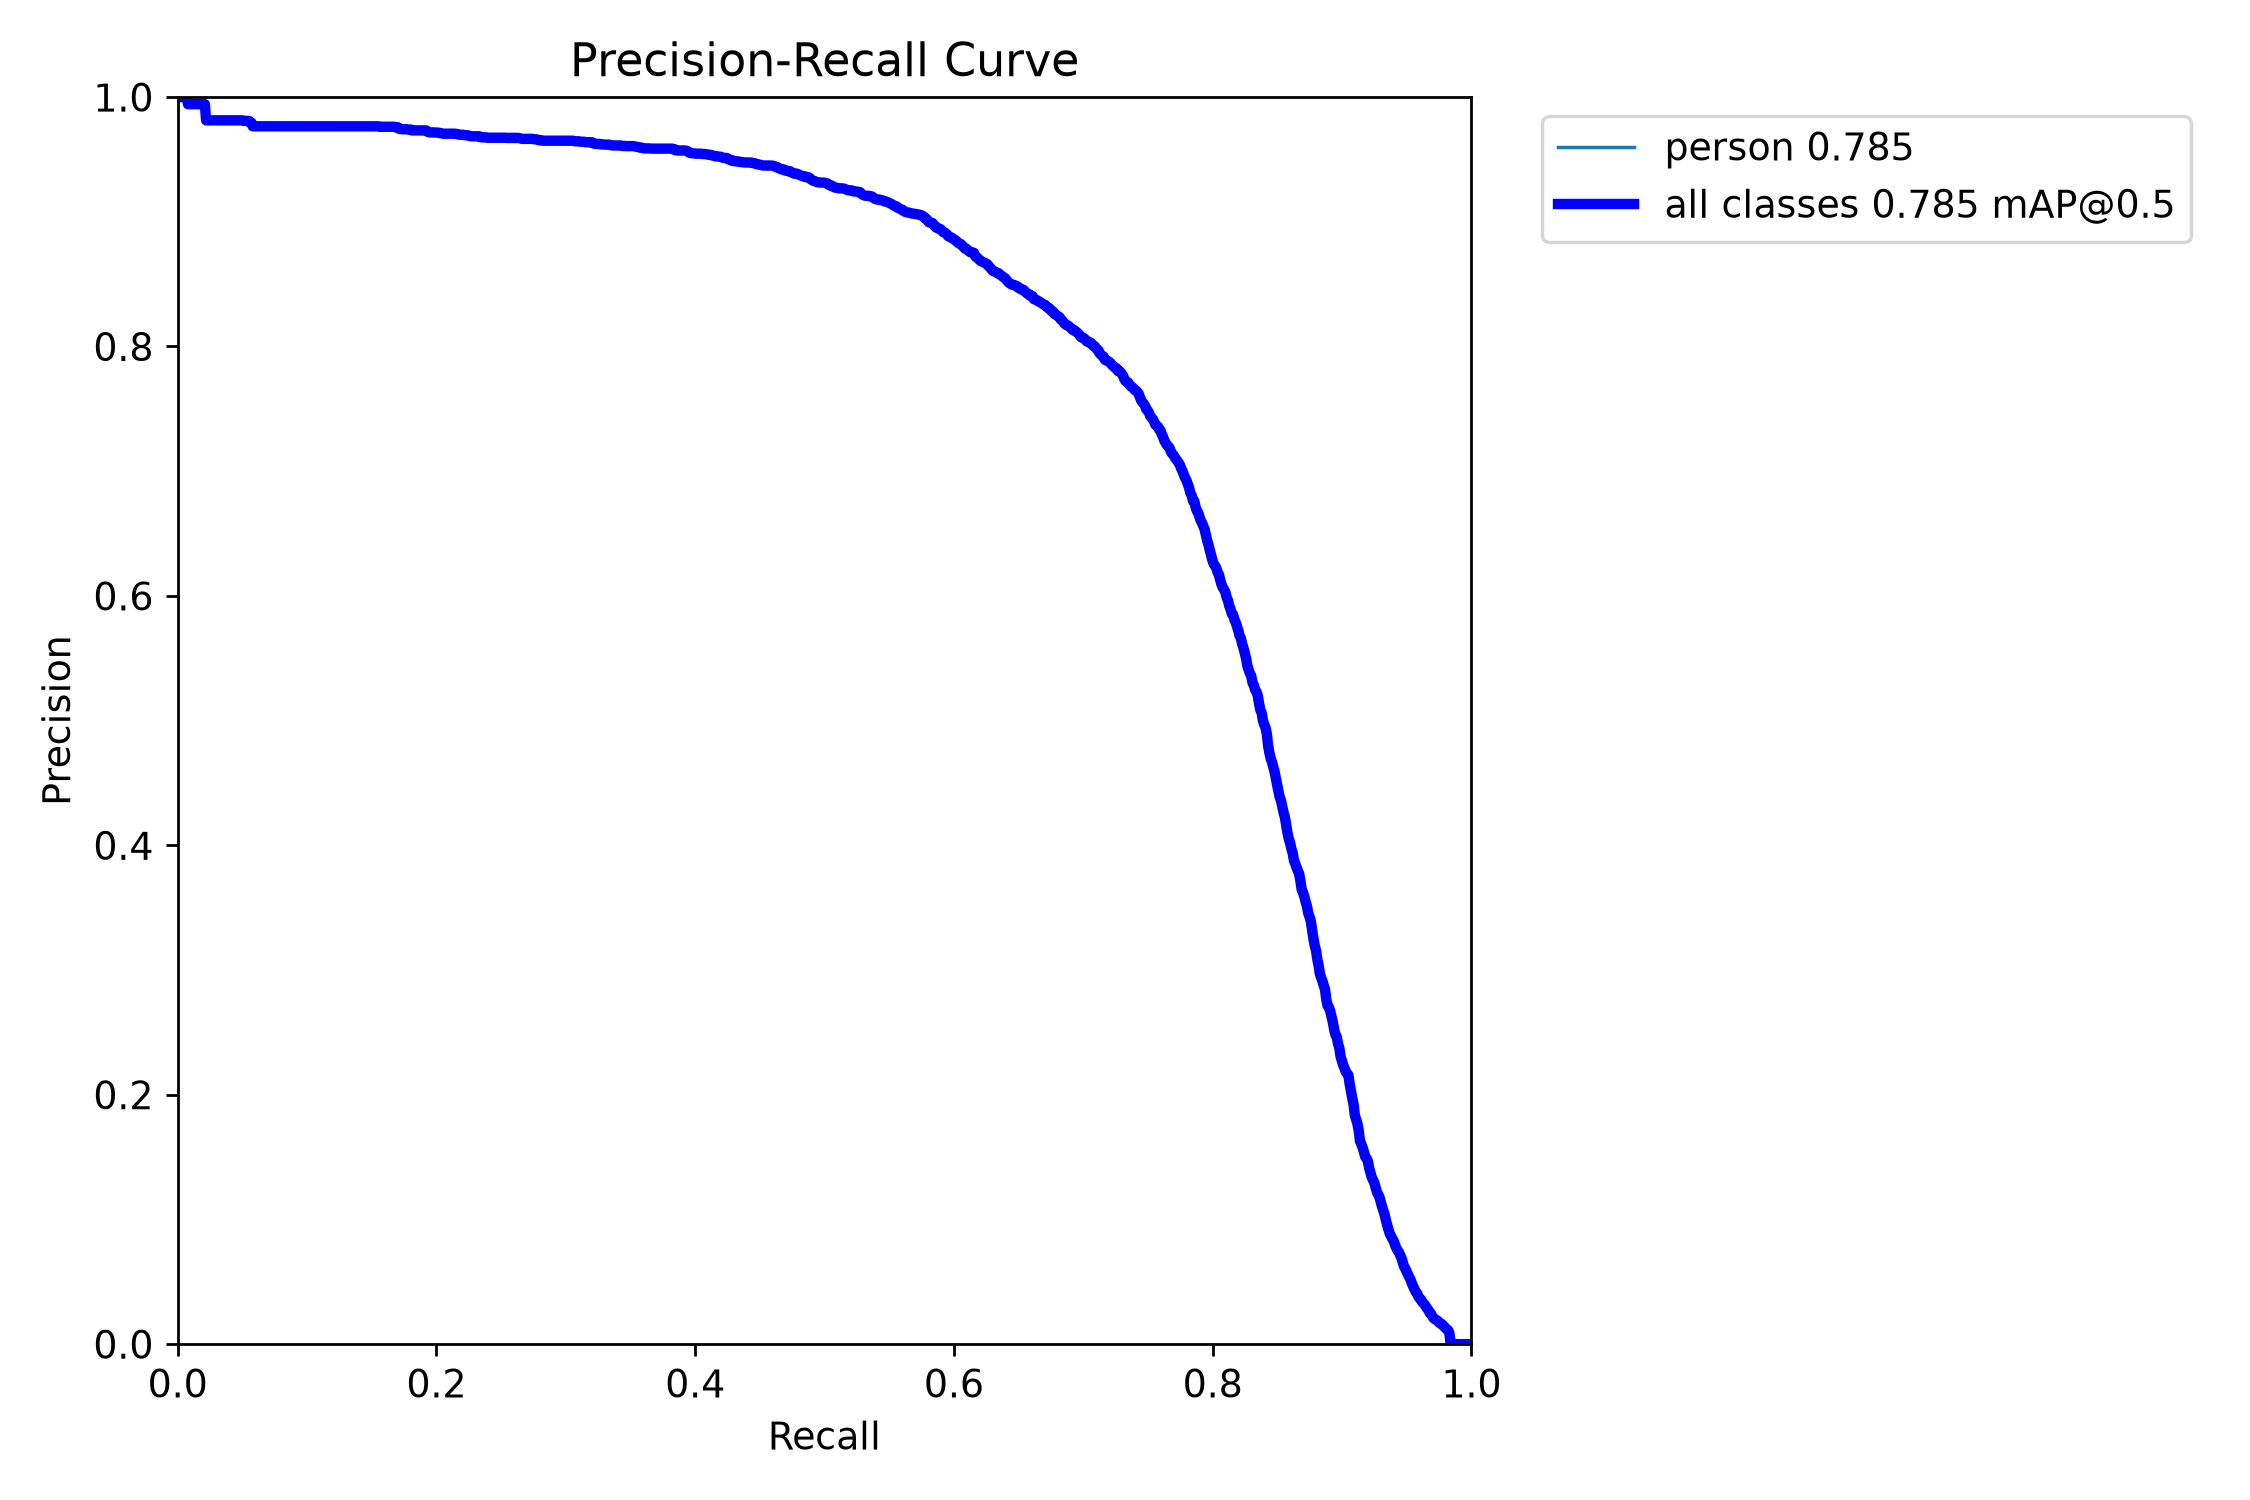

BoxF1_curve.png exists: True


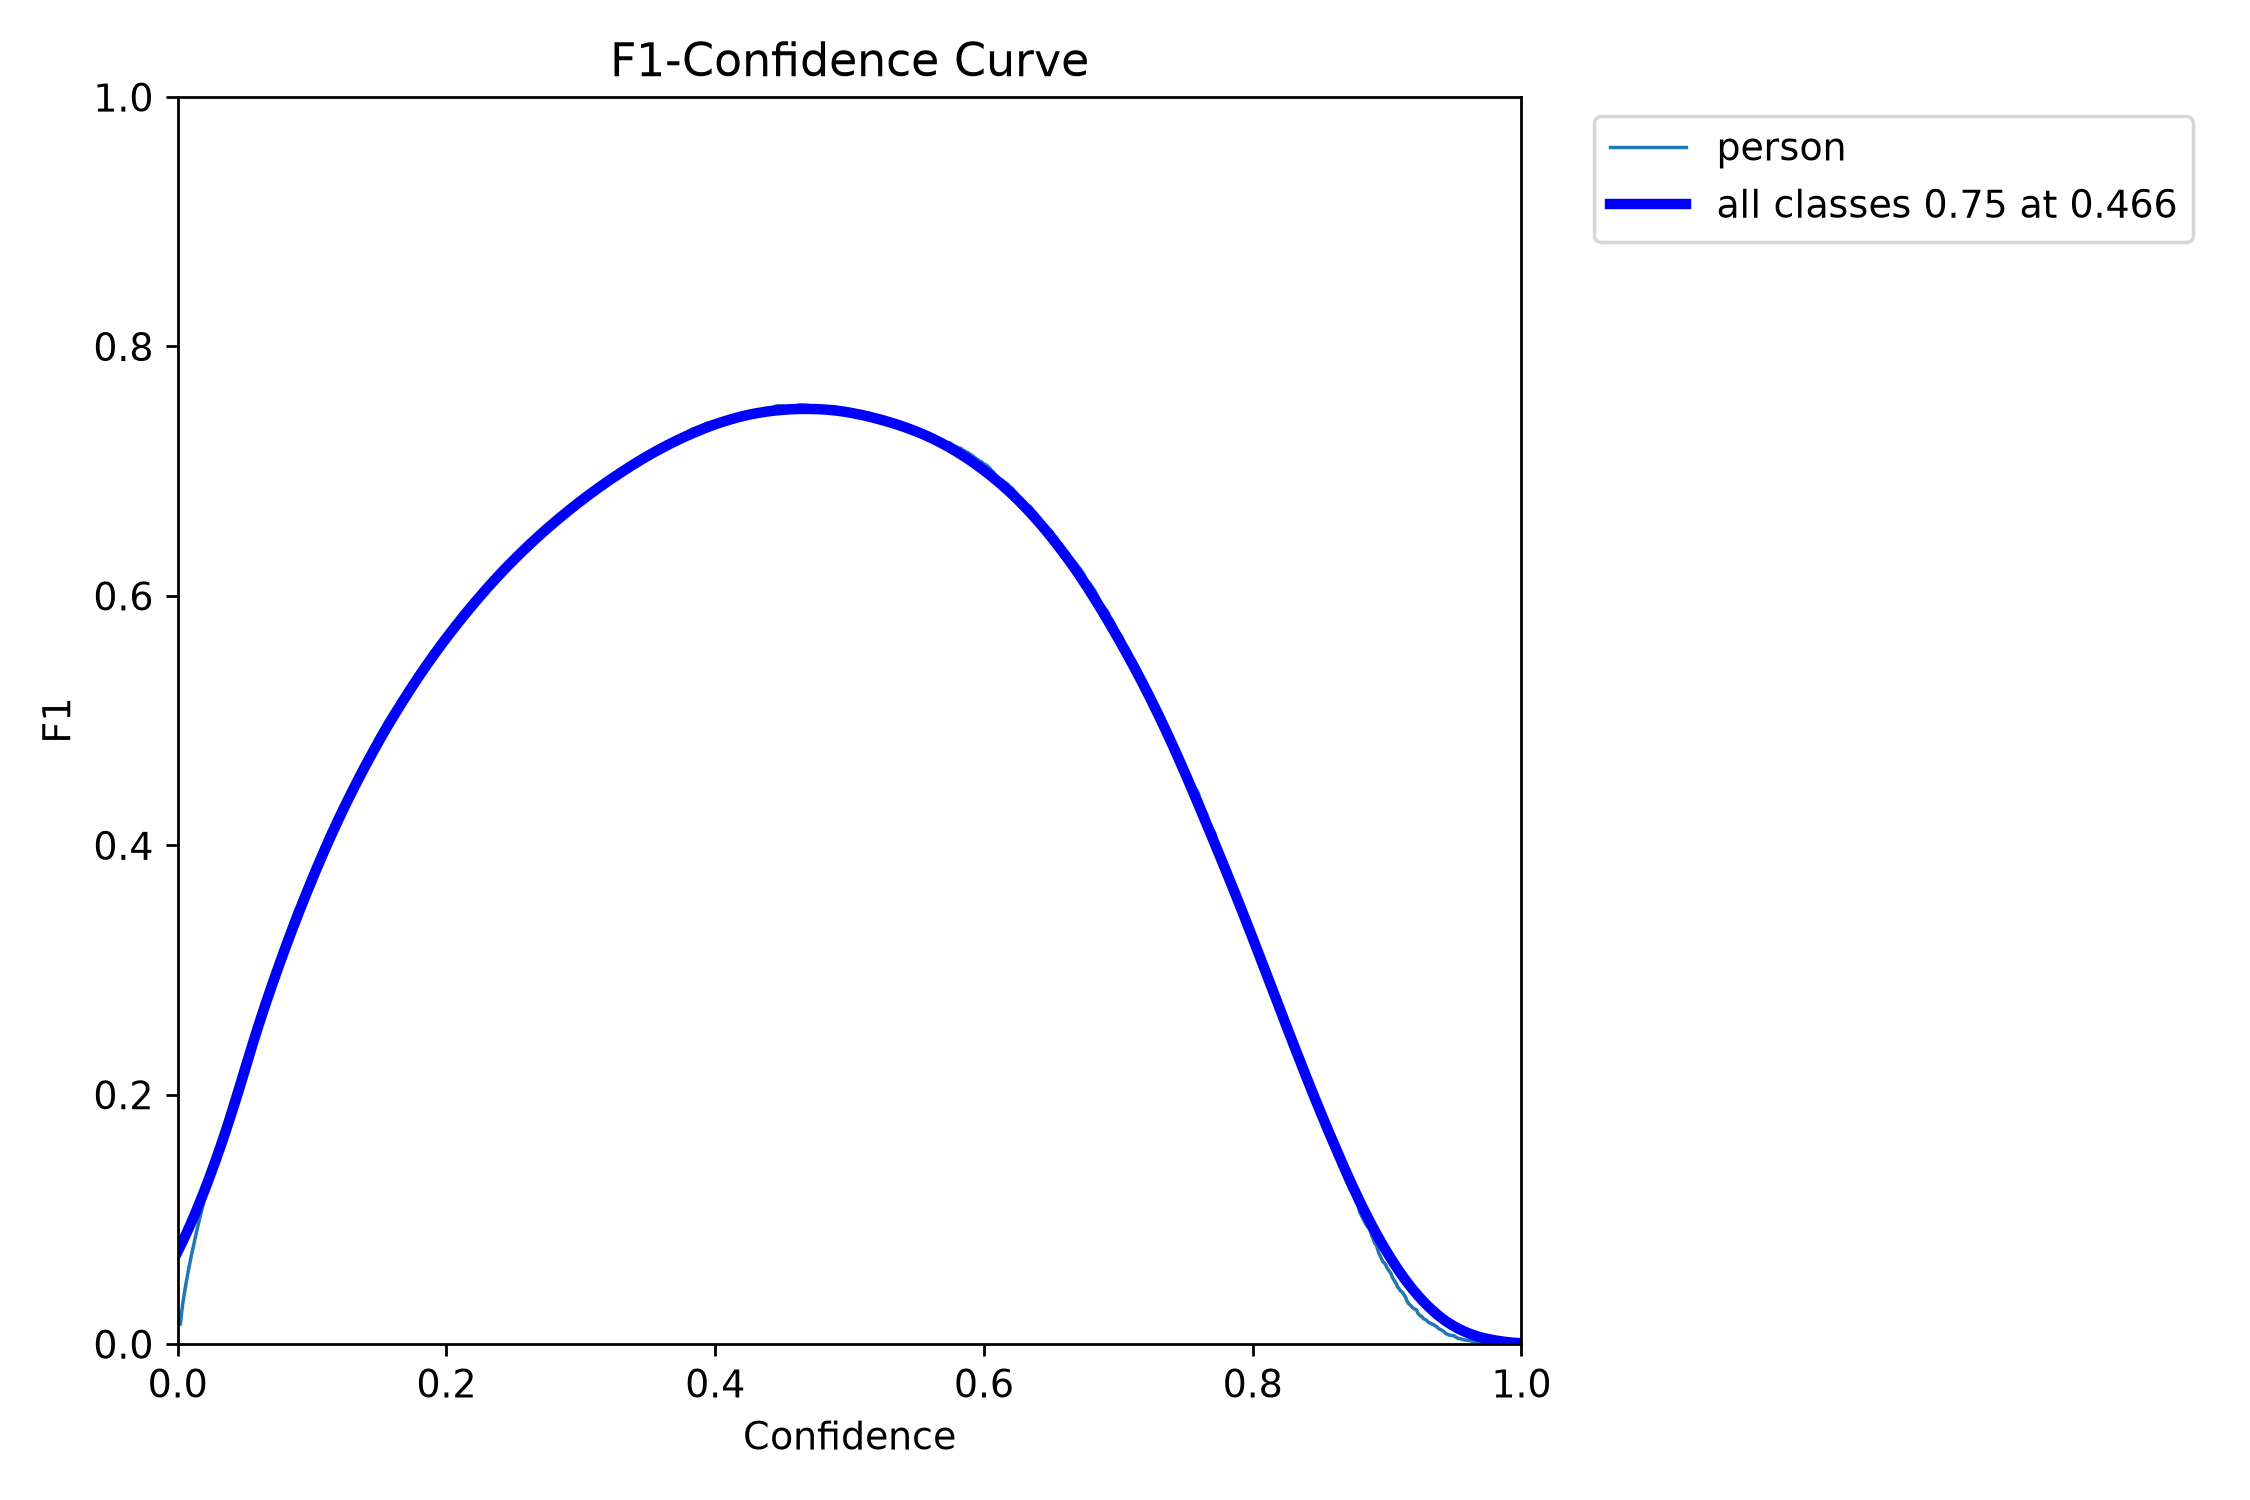

BoxP_curve.png exists: True


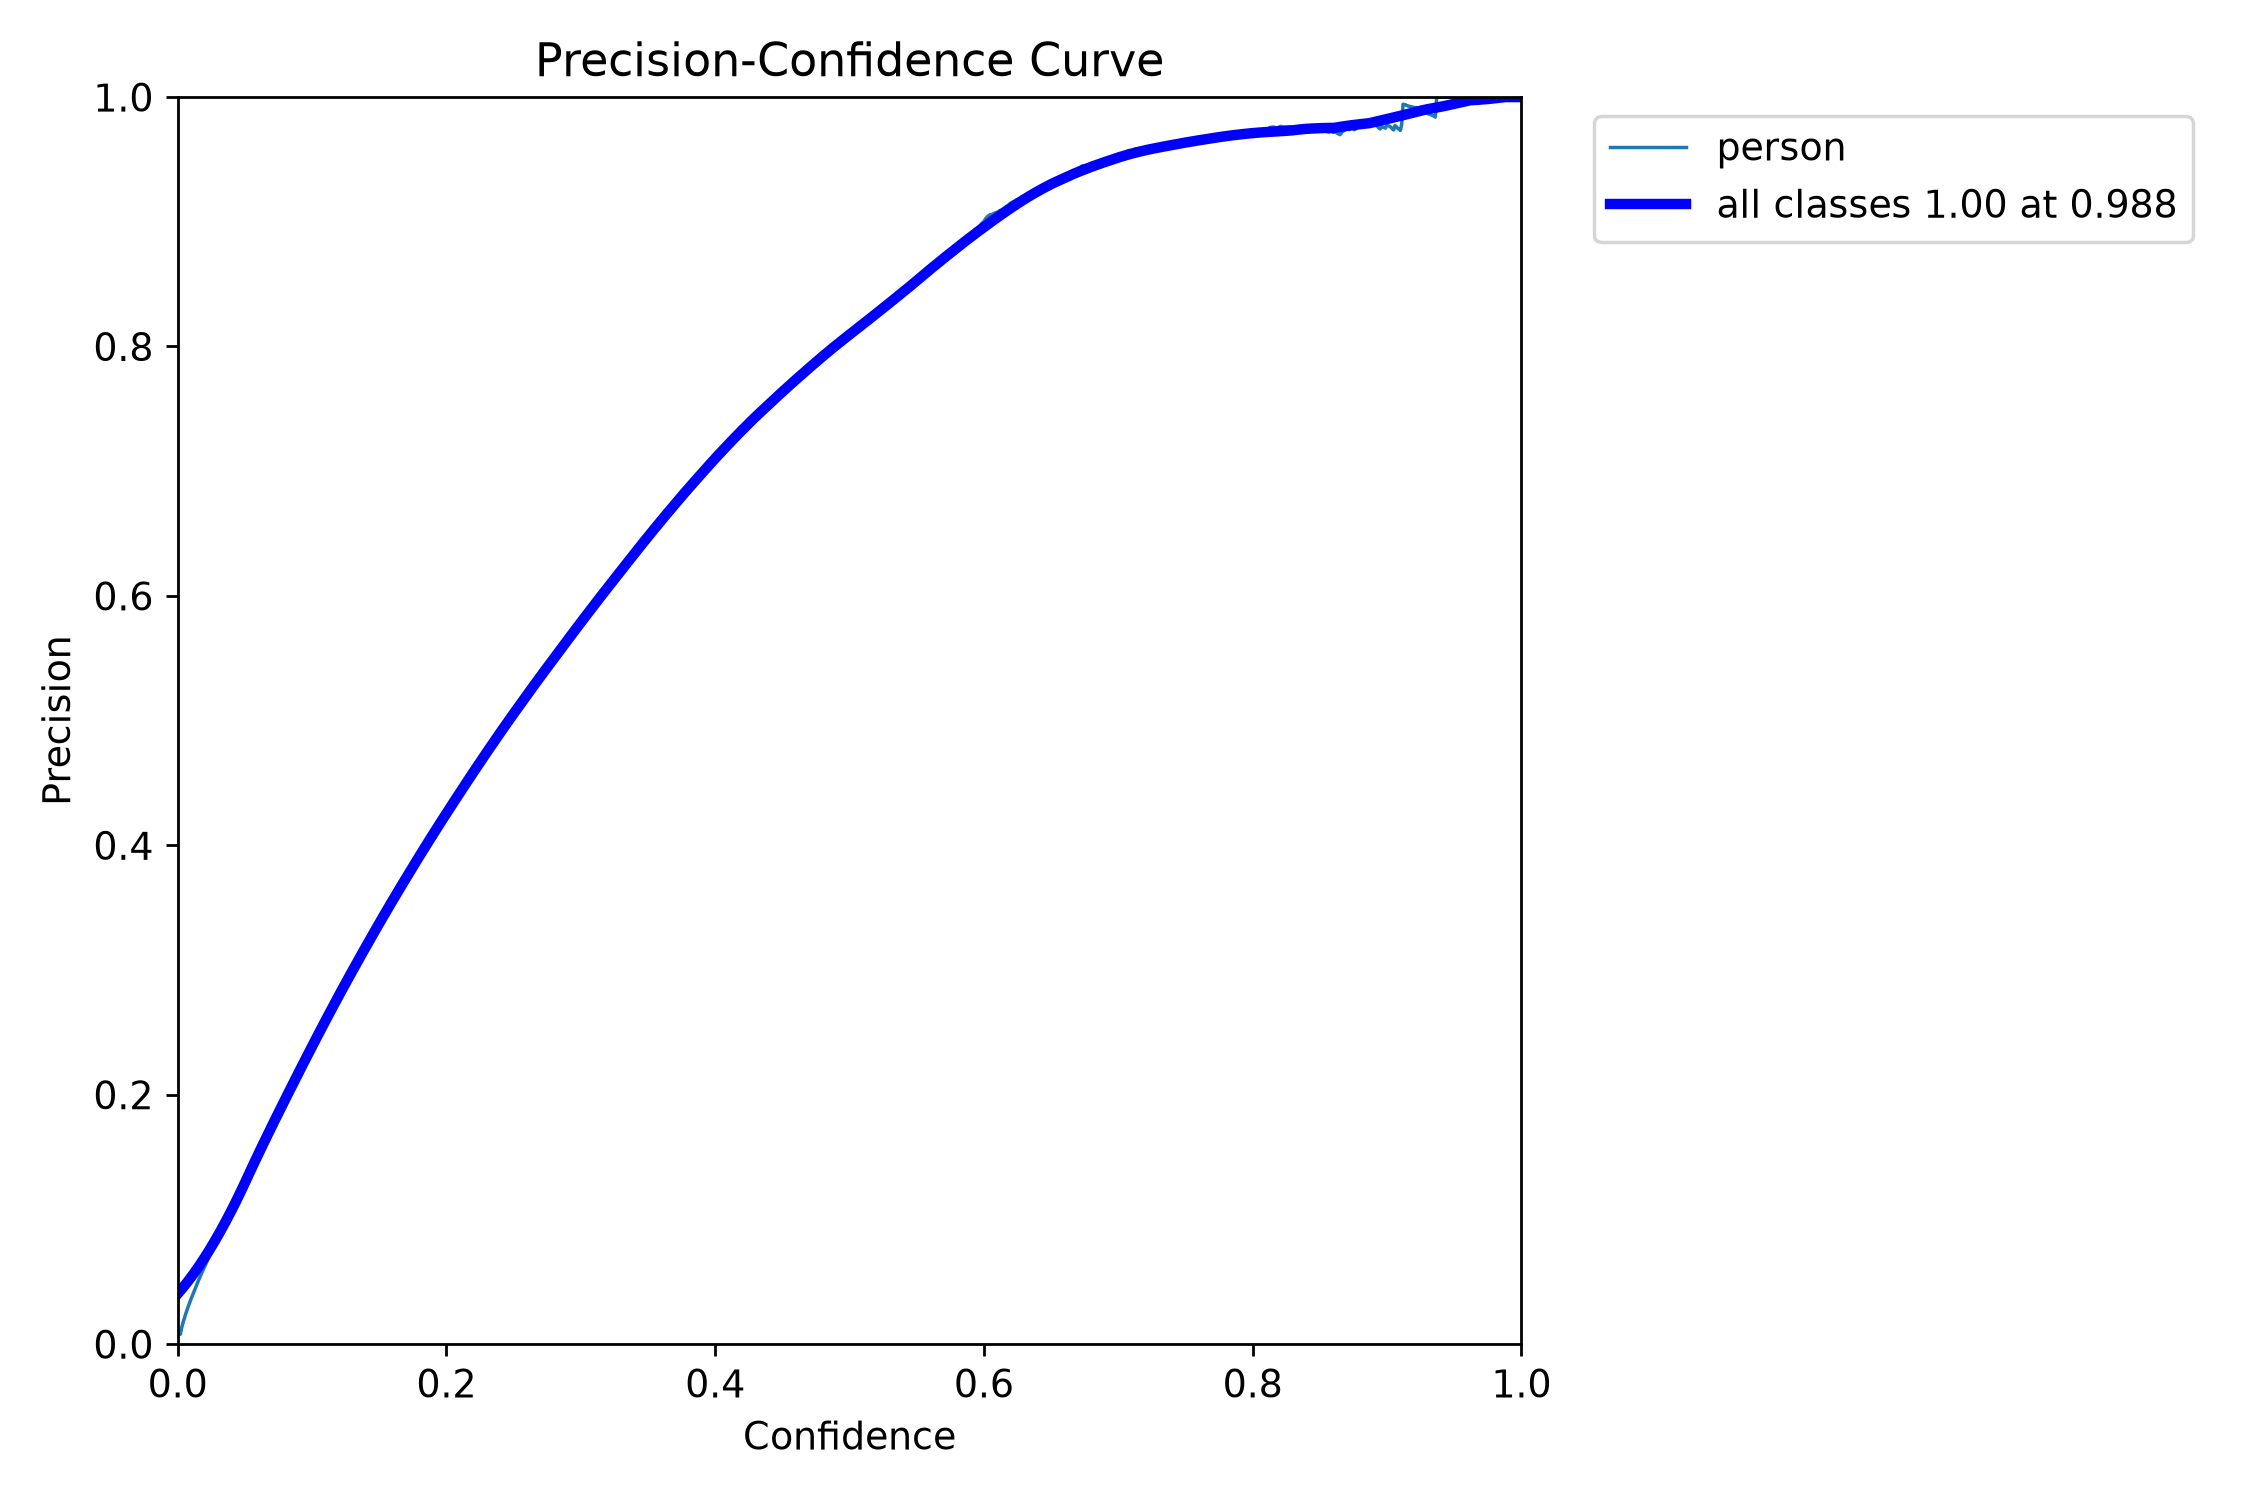

BoxR_curve.png exists: True


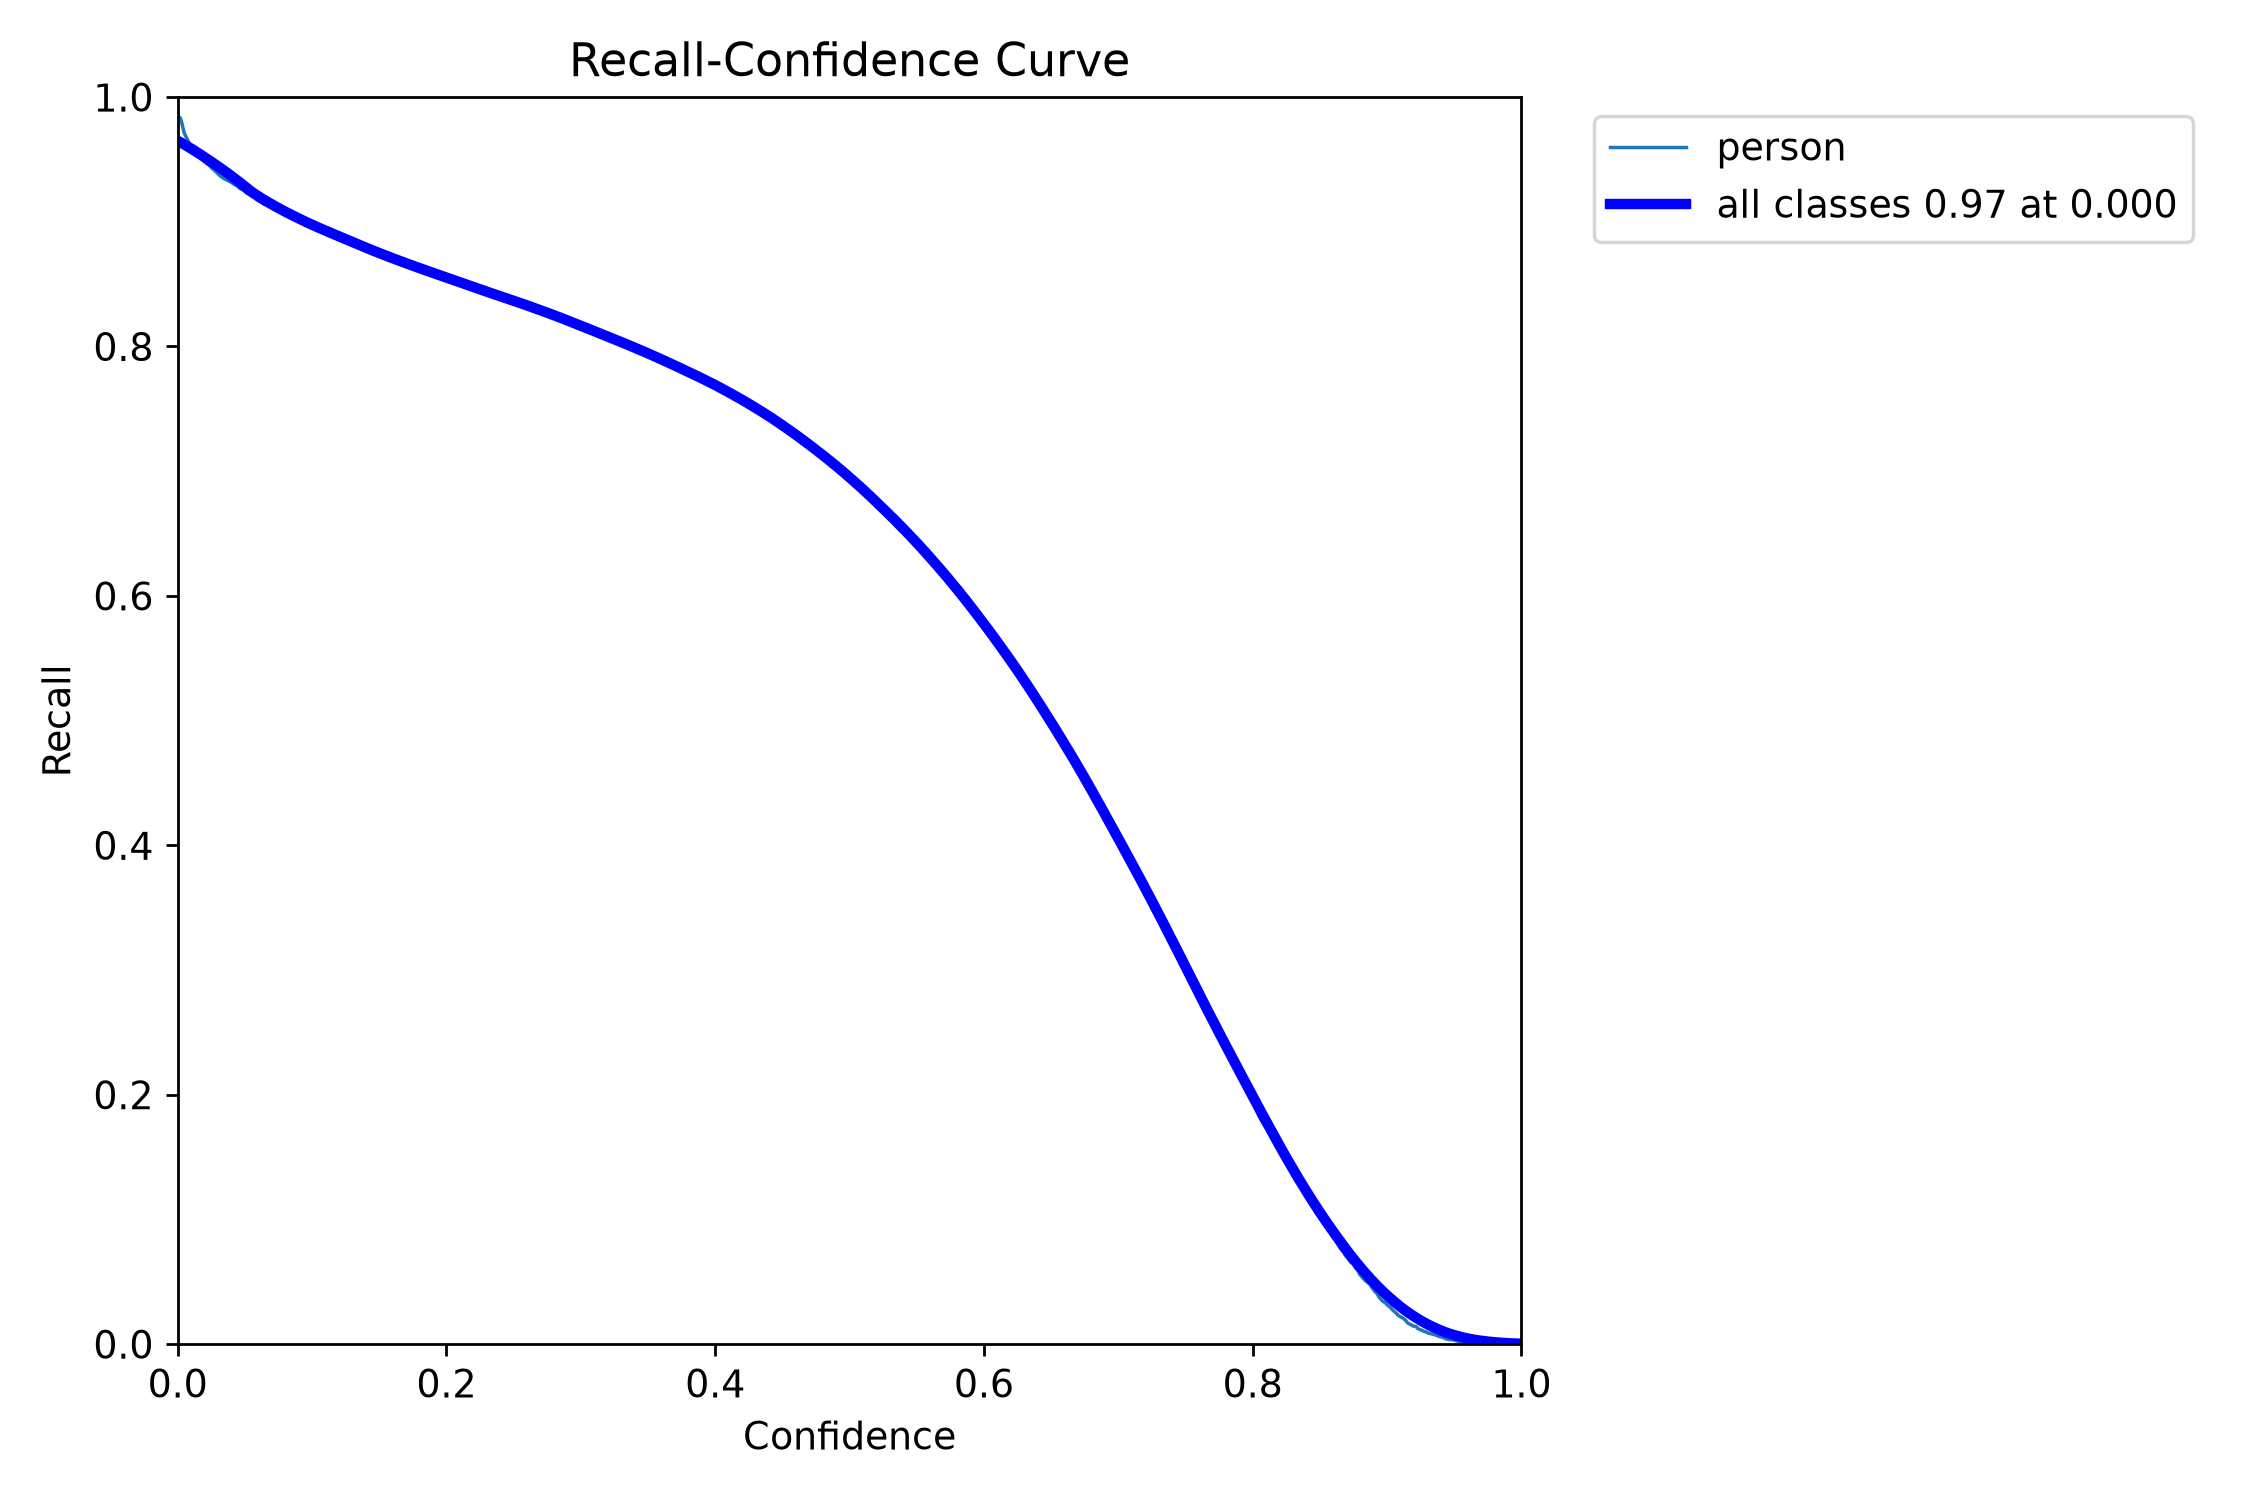

In [ ]:
TEST_RESULTS_ROOT = RUNS_ROOT / TEST_EVALUATION_NAME

for filename in [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
]:
    file_path = TEST_RESULTS_ROOT / filename
    print(filename, "exists:", file_path.exists())

    if file_path.exists():
        display(IPImage(filename=str(file_path)))


In [ ]:
test_metrics_path = TEST_RESULTS_ROOT / "test_metrics.json"

if "test_metrics_dict" in globals():
    TEST_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    test_metrics_path.write_text(json.dumps(test_metrics_dict, indent=2))
    print("Saved test metrics to:", test_metrics_path)
else:
    print("No test metrics dict in memory yet. Run test evaluation first.")


Saved test metrics to: /home/arjun/lli-pedestrian/runs/pedestrian_zerodce_yolo11n_test/test_metrics.json


In [ ]:
SAMPLE_PREDICTION_NAME = "sample_predictions_yolo11_notebook"
RUN_SAMPLE_PREDICTIONS = True

sample_image_paths = sorted((YOLO_ROOT / "images" / "test").glob("*.jpg"))[:12]

if RUN_SAMPLE_PREDICTIONS:
    prediction_results = model.predict(
        source=[str(path) for path in sample_image_paths],
        imgsz=640,
        conf=0.25,
        device=0,
        save=True,
        save_conf=True,
        project=str(RUNS_ROOT),
        name=SAMPLE_PREDICTION_NAME,
        exist_ok=True,
        verbose=True,
    )

SAMPLE_PREDICTIONS_ROOT = RUNS_ROOT / SAMPLE_PREDICTION_NAME
print("Sample predictions directory:", SAMPLE_PREDICTIONS_ROOT)



0: 512x640 5 persons, 2.0ms
1: 512x640 1 person, 2.0ms
2: 512x640 8 persons, 2.0ms
3: 512x640 2 persons, 2.0ms
4: 512x640 3 persons, 2.0ms
5: 512x640 7 persons, 2.0ms
6: 512x640 5 persons, 2.0ms
7: 512x640 3 persons, 2.0ms
8: 512x640 13 persons, 2.0ms
9: 512x640 2 persons, 2.0ms
10: 512x640 5 persons, 2.0ms
11: 512x640 3 persons, 2.0ms
Speed: 2.8ms preprocess, 2.0ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /home/arjun/lli-pedestrian/runs/sample_predictions_yolo11_notebook
Sample predictions directory: /home/arjun/lli-pedestrian/runs/sample_predictions_yolo11_notebook


Prediction images: 12
190001.jpg


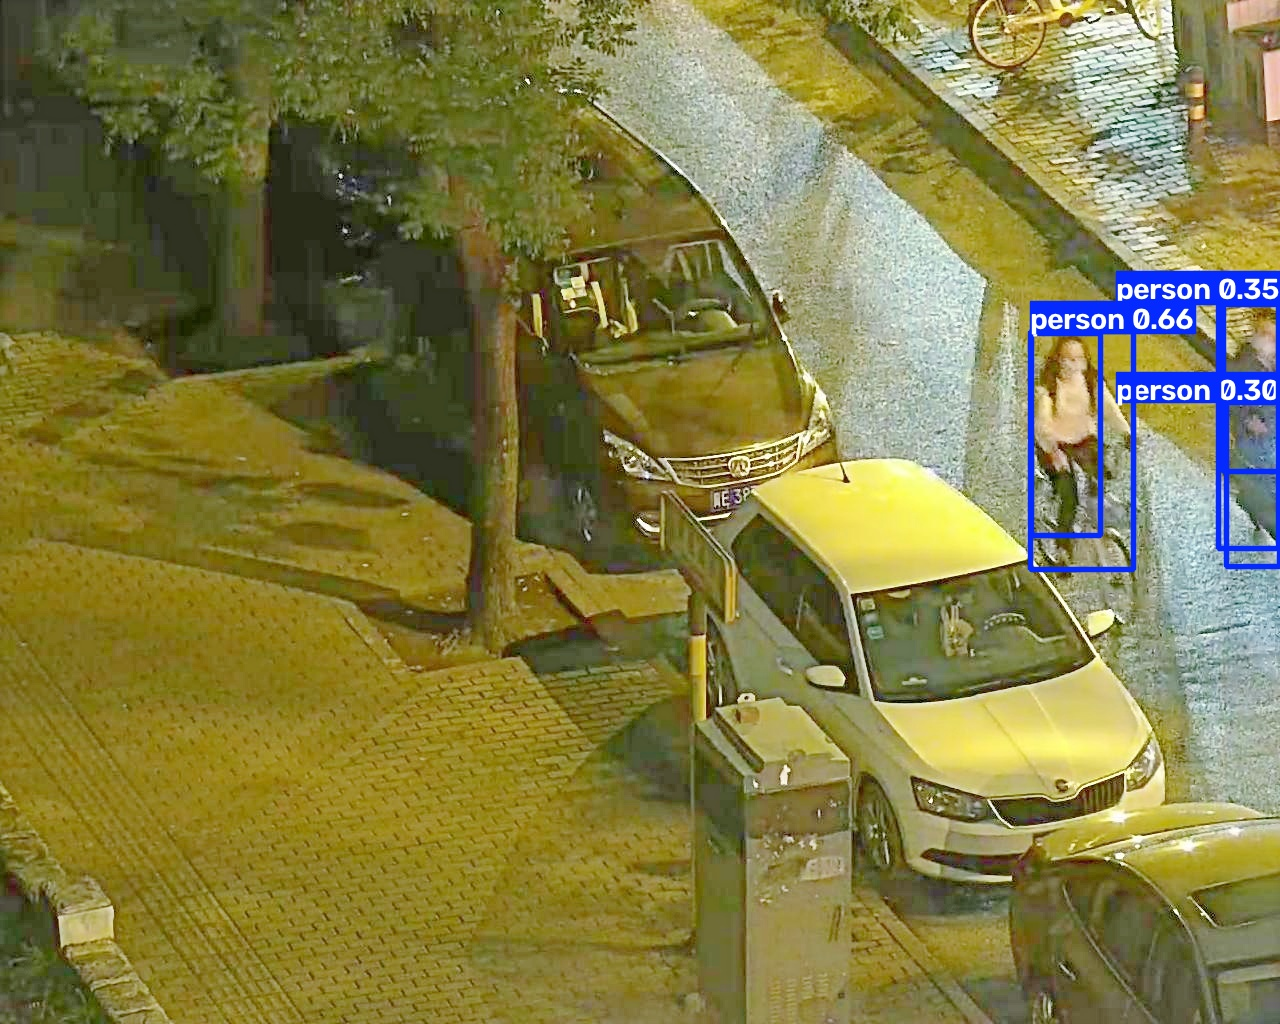

190002.jpg


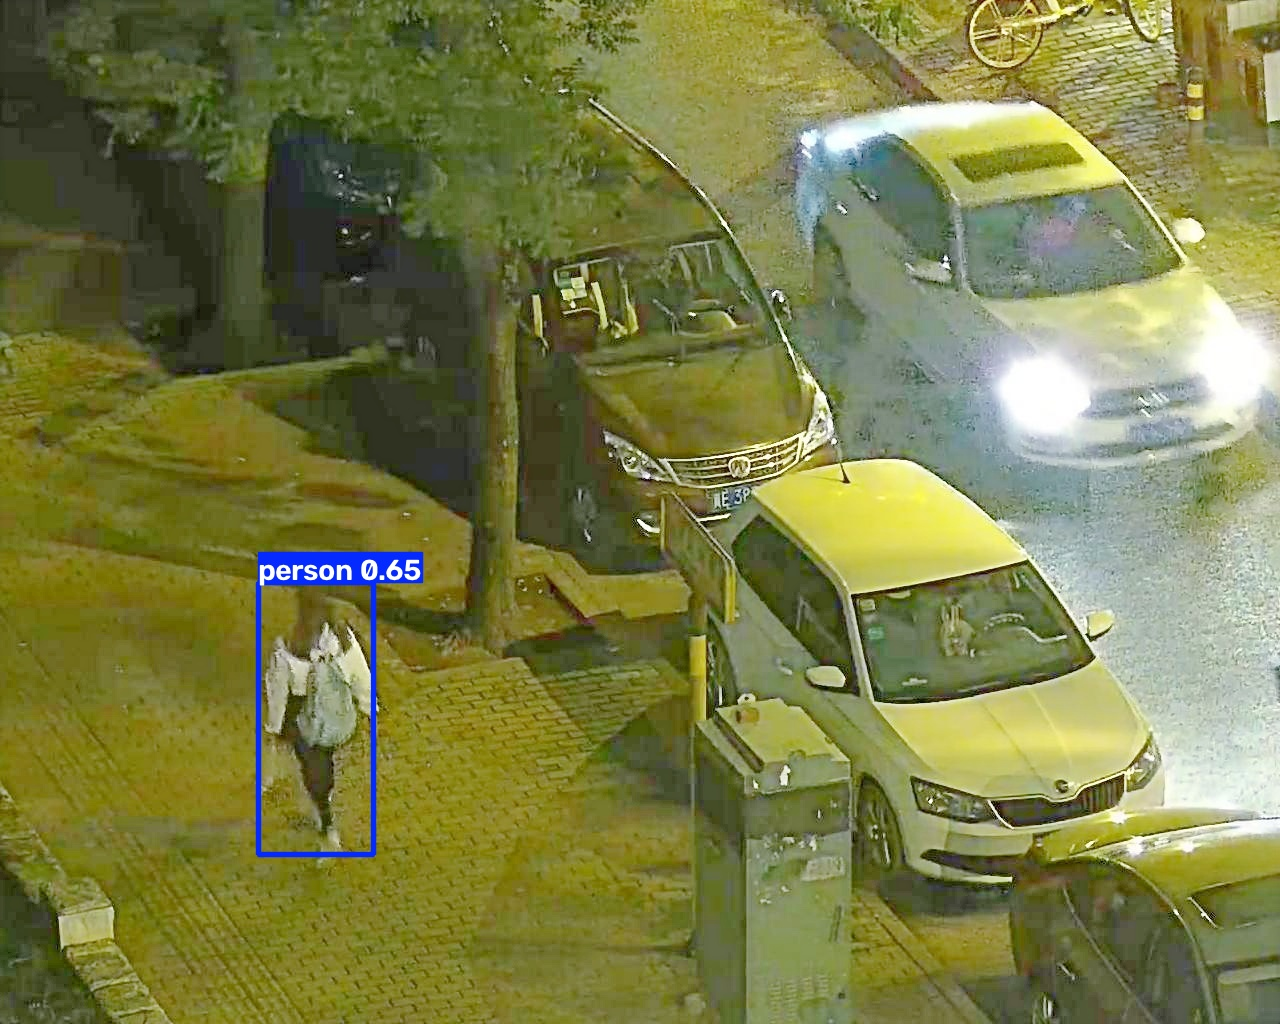

190003.jpg


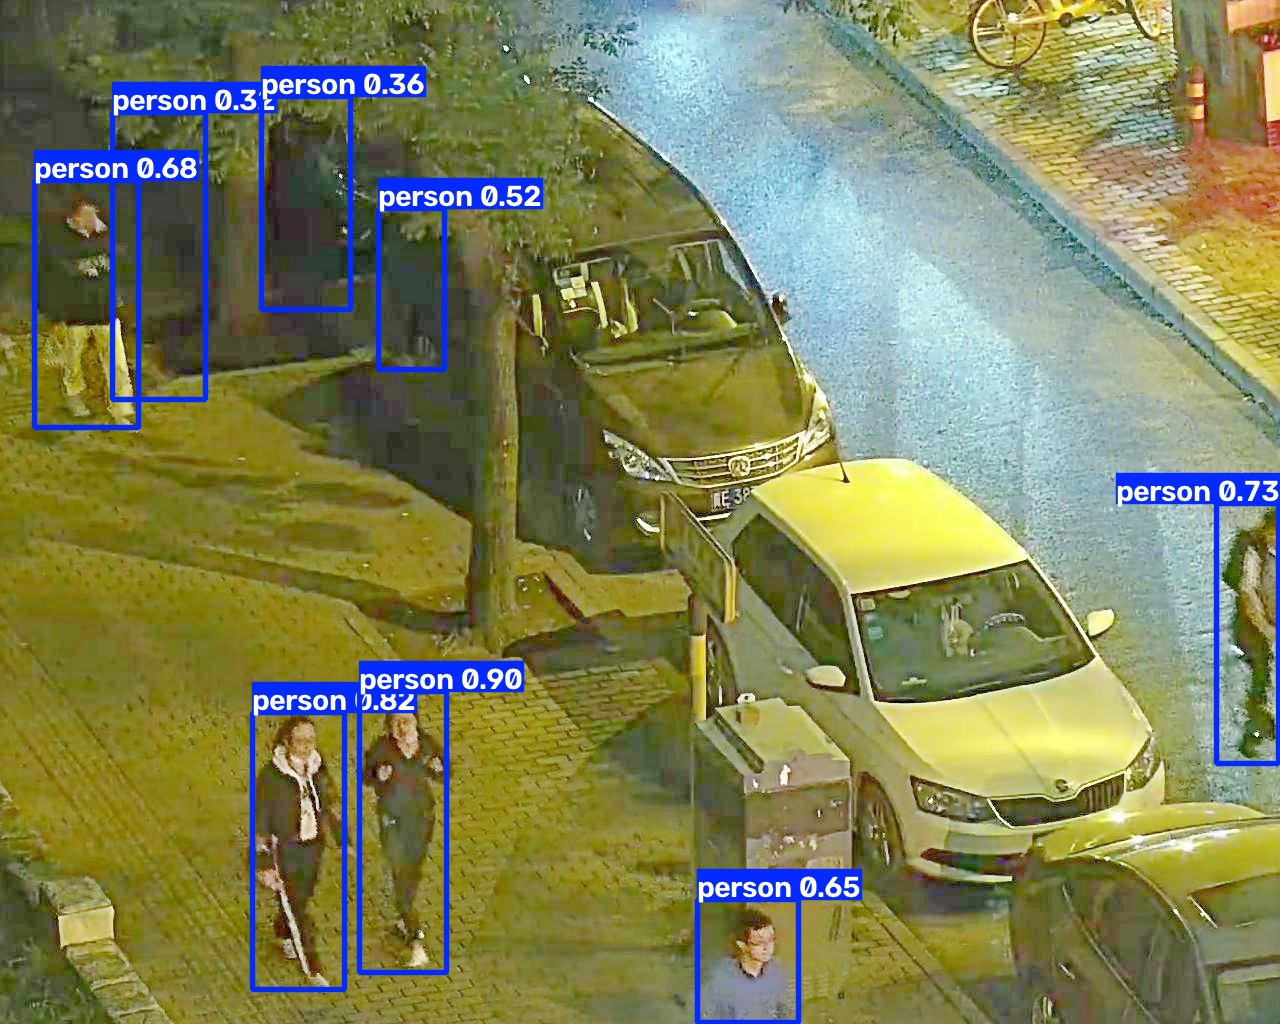

190004.jpg


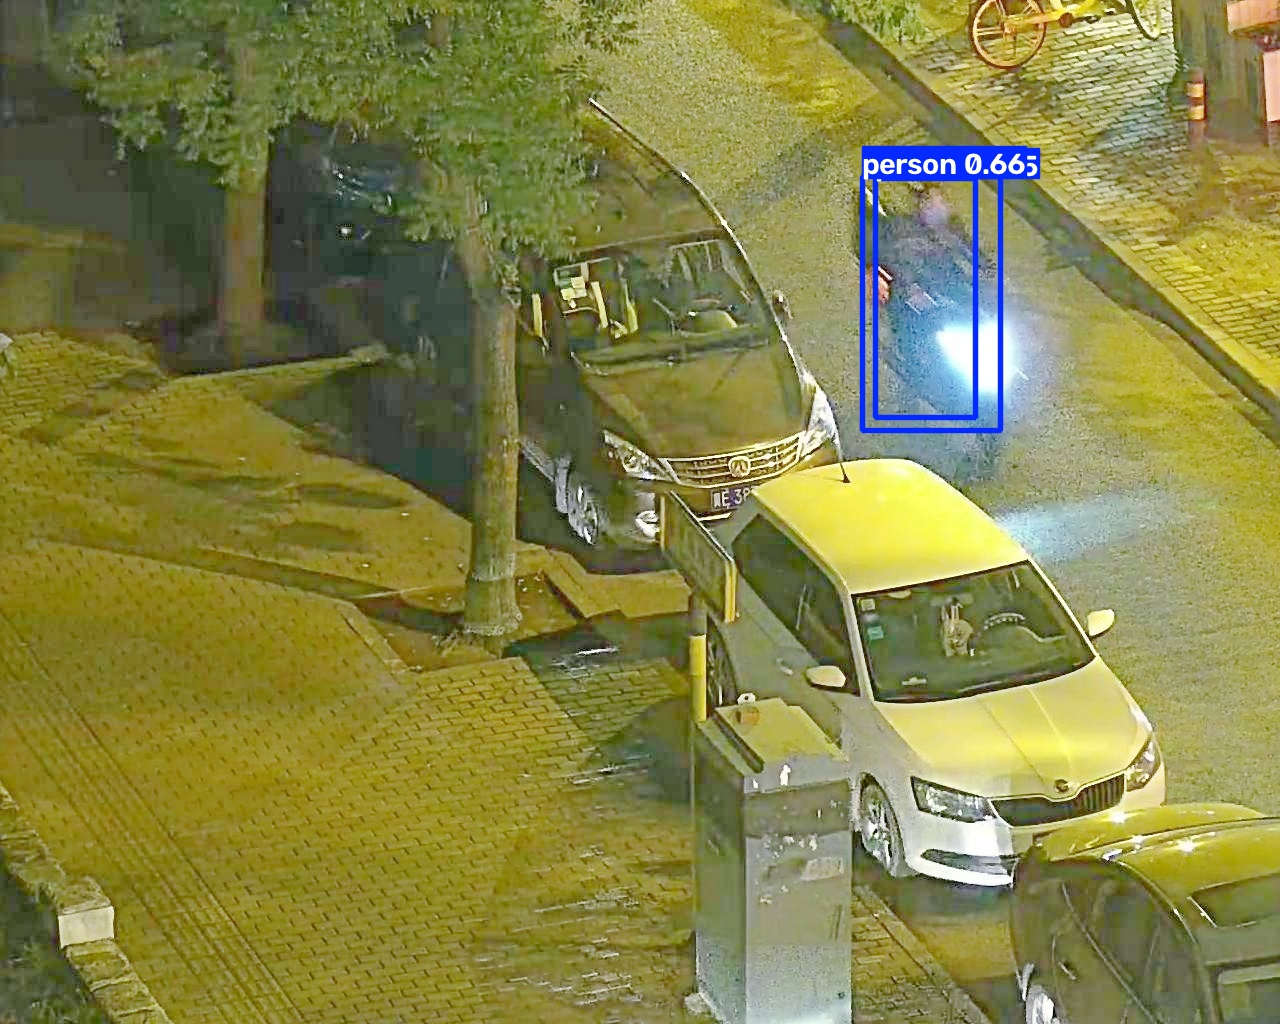

190005.jpg


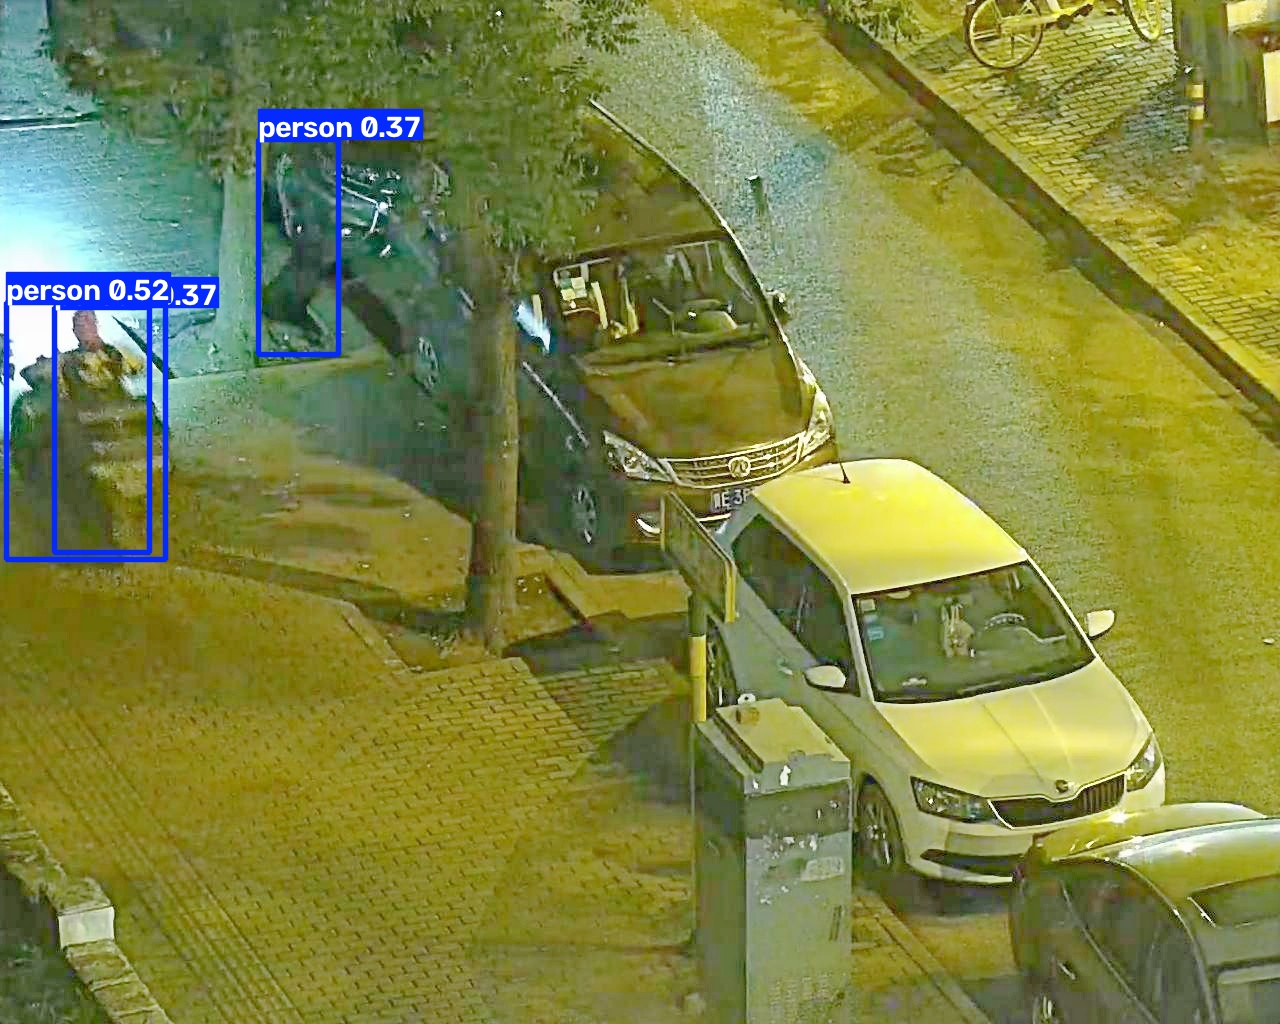

190006.jpg


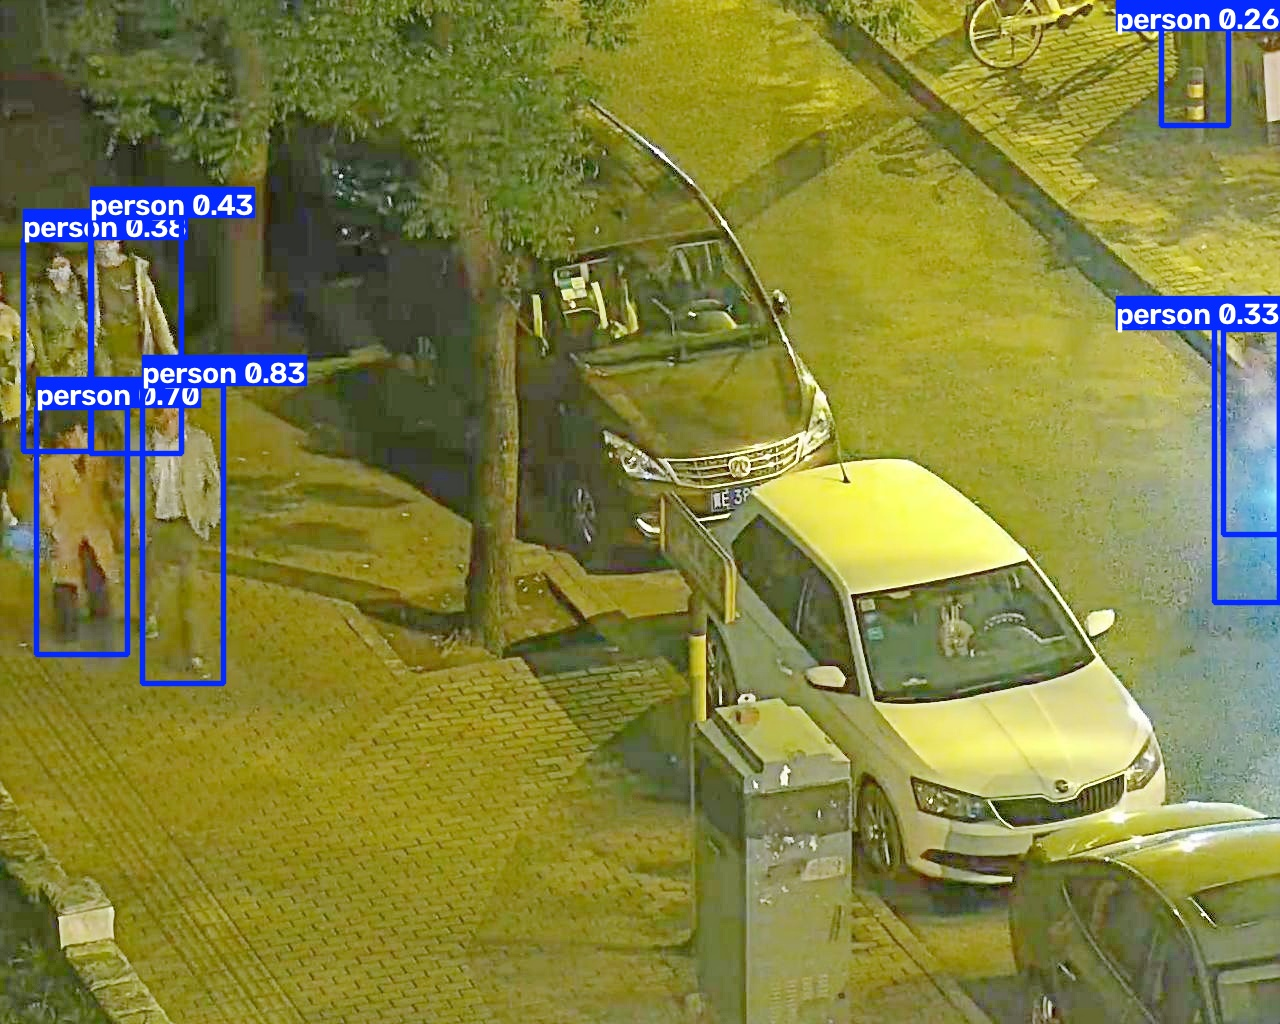

In [ ]:
prediction_files = sorted(SAMPLE_PREDICTIONS_ROOT.glob("*.jpg"))

print("Prediction images:", len(prediction_files))

for prediction_file in prediction_files[:6]:
    print(prediction_file.name)
    display(IPImage(filename=str(prediction_file)))


In [ ]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


def calculate_image_metrics(image_path):
    """
    Calculate simple image-level enhancement metrics.

    These metrics describe changes in illumination and visible structure.
    They do not directly measure pedestrian-detection accuracy.
    """
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if image is None:
        raise ValueError(f"Unable to read image: {image_path}")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    brightness = float(gray.mean())

    min_value = int(gray.min())
    max_value = int(gray.max())
    dynamic_range = float(max_value - min_value)

    # Count dark pixels as an approximate background-area measure.
    _, thresholded = cv2.threshold(
        gray,
        50,
        255,
        cv2.THRESH_BINARY_INV,
    )
    dark_pixel_area = int(cv2.countNonZero(thresholded))

    # Count external contours as a basic structural-detail measure.
    edges = cv2.Canny(gray, 50, 150)
    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    return {
        "image_name": Path(image_path).name,
        "brightness": brightness,
        "dynamic_range": dynamic_range,
        "dark_pixel_area": dark_pixel_area,
        "contour_count": len(contours),
    }

In [ ]:
# Original low-light images.
ORIGINAL_IMAGES_DIR = VISIBLE_ROOT / "test"

# Enhanced images produced by Zero-DCE.
# Replace this path with the output directory used by your notebook.
ENHANCED_IMAGES_DIR = PROCESSED_IMAGES_ROOT / "test"

print("Original images:", ORIGINAL_IMAGES_DIR)
print("Enhanced images:", ENHANCED_IMAGES_DIR)

if not ORIGINAL_IMAGES_DIR.exists():
    raise FileNotFoundError(
        f"Original image directory does not exist: {ORIGINAL_IMAGES_DIR}"
    )

if not ENHANCED_IMAGES_DIR.exists():
    raise FileNotFoundError(
        f"Enhanced image directory does not exist: {ENHANCED_IMAGES_DIR}"
    )

Original images: /home/arjun/lli-pedestrian/data/llvip/LLVIP/visible/test
Enhanced images: /home/arjun/lli-pedestrian/data/processed/images/test


In [ ]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}


def collect_metrics(image_dir, image_group):
    image_paths = sorted(
        path
        for path in Path(image_dir).iterdir()
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )

    if not image_paths:
        raise FileNotFoundError(
            f"No supported images found in: {image_dir}"
        )

    rows = []

    for image_path in tqdm(
        image_paths,
        desc=f"Calculating metrics for {image_group}",
    ):
        metrics = calculate_image_metrics(image_path)
        metrics["image_group"] = image_group
        rows.append(metrics)

    return pd.DataFrame(rows)


original_metrics_df = collect_metrics(
    ORIGINAL_IMAGES_DIR,
    "original",
)

enhanced_metrics_df = collect_metrics(
    ENHANCED_IMAGES_DIR,
    "enhanced",
)

enhancement_metrics_df = pd.concat(
    [
        original_metrics_df,
        enhanced_metrics_df,
    ],
    ignore_index=True,
)

enhancement_metrics_df.head()

Calculating metrics for original:   0%|          | 0/3463 [00:00<?, ?it/s]

Calculating metrics for enhanced:   0%|          | 0/3463 [00:00<?, ?it/s]

,image_name,brightness,dynamic_range,dark_pixel_area,contour_count,image_group
0,190001.jpg,58.646639,255.0,821732,2634,original
1,190002.jpg,55.665163,255.0,891735,1746,original
2,190003.jpg,65.037041,254.0,785375,2497,original
3,190004.jpg,61.097457,255.0,741565,2231,original
4,190005.jpg,58.919350,255.0,764862,1966,original


In [ ]:
metric_columns = [
    "brightness",
    "dynamic_range",
    "dark_pixel_area",
    "contour_count",
]

summary_metrics_df = (
    enhancement_metrics_df
    .groupby("image_group")[metric_columns]
    .mean()
    .round(2)
)

display(summary_metrics_df)

original_summary = summary_metrics_df.loc["original"]
enhanced_summary = summary_metrics_df.loc["enhanced"]

comparison_df = pd.DataFrame(
    {
        "original_mean": original_summary,
        "enhanced_mean": enhanced_summary,
        "absolute_change": enhanced_summary - original_summary,
        "percentage_change": (
            (enhanced_summary - original_summary)
            / original_summary.replace(0, np.nan)
            * 100
        ),
    }
).round(2)

display(comparison_df)

,brightness,dynamic_range,dark_pixel_area,contour_count
image_group,,,,
enhanced,107.35,254.40,104790.75,3919.20
original,44.63,254.42,960711.68,2433.67


,original_mean,enhanced_mean,absolute_change,percentage_change
brightness,44.63,107.35,62.72,140.53
dynamic_range,254.42,254.40,-0.02,-0.01
dark_pixel_area,960711.68,104790.75,-855920.93,-89.09
contour_count,2433.67,3919.20,1485.53,61.04


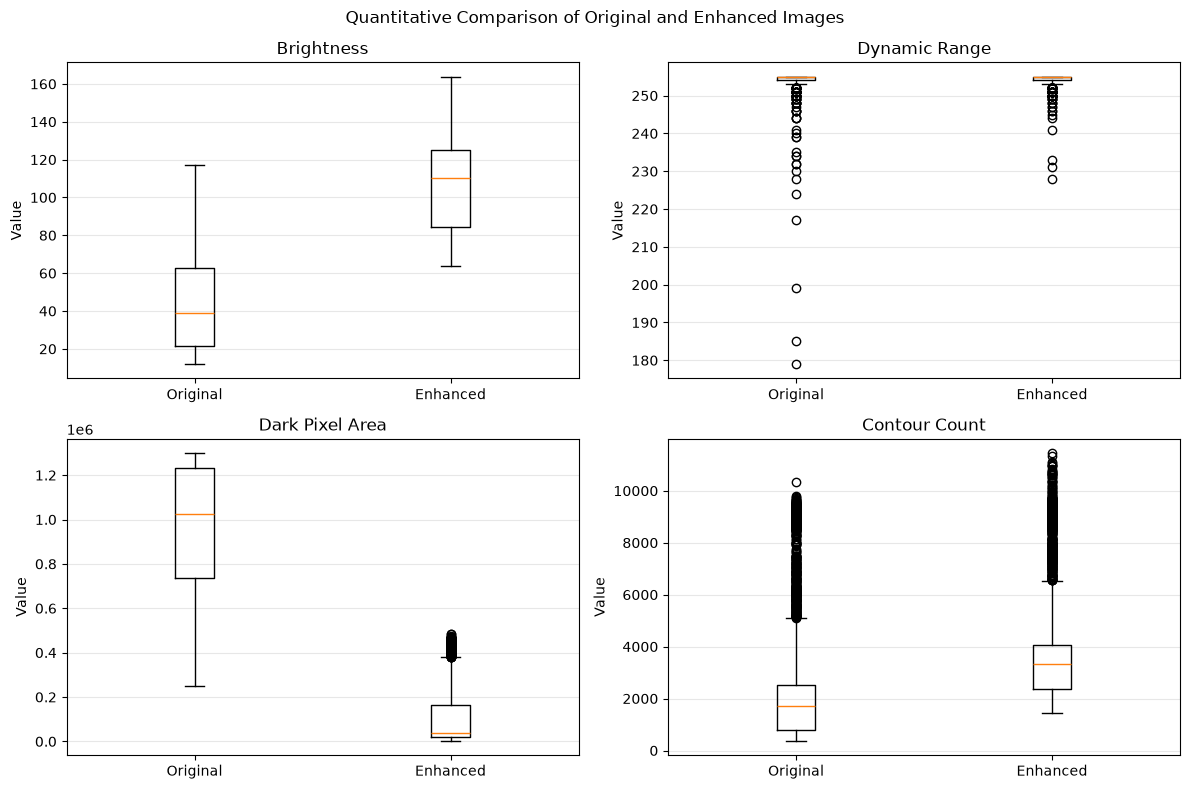

In [ ]:
plot_metrics = [
    "brightness",
    "dynamic_range",
    "dark_pixel_area",
    "contour_count",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8),
)

axes = axes.ravel()

for axis, metric in zip(axes, plot_metrics):
    values = [
        enhancement_metrics_df.loc[
            enhancement_metrics_df["image_group"] == group,
            metric,
        ].dropna().to_numpy()
        for group in ["original", "enhanced"]
    ]

    axis.boxplot(
        values,
        tick_labels=["Original", "Enhanced"],
    )

    axis.set_title(metric.replace("_", " ").title())
    axis.set_ylabel("Value")
    axis.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Quantitative Comparison of Original and Enhanced Images"
)
plt.tight_layout()
plt.show()

In [ ]:
METRICS_OUTPUT_DIR = RUNS_ROOT / "enhancement_metrics"
METRICS_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

enhancement_metrics_df.to_csv(
    METRICS_OUTPUT_DIR / "per_image_enhancement_metrics.csv",
    index=False,
)

summary_metrics_df.to_csv(
    METRICS_OUTPUT_DIR / "enhancement_metrics_summary.csv",
)

comparison_df.to_csv(
    METRICS_OUTPUT_DIR / "enhancement_metrics_comparison.csv",
)

print("Saved metric files to:", METRICS_OUTPUT_DIR)

Saved metric files to: /home/arjun/lli-pedestrian/runs/enhancement_metrics


In [27]:
%load_ext tensorboard
%tensorboard --logdir /home/arjun/lli-pedestrian/runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 1348209), started 0:00:53 ago. (Use '!kill 1348209' to kill it.)

## References
1. 